# Blind Resonator — Time-Window Grid Search & Analysis

Trains a **Random Forest** (GridSearchCV, 5-fold stratified CV) on each of **10 time windows** (10 – 2000 ms) for the Blind Resonator.

### Pipeline
1. Load spike-count CSVs from `Dataset/Blind/DIFF_WINDOW/`
2. For each time window, run GridSearchCV to find the best hyperparameters
3. Generate per-window confusion matrices (absolute + normalized)
4. Compare performance across all time windows

### Features
| Feature | Description |
|---------|-------------|
| N1–N5   | Spike counts from 5 neuromorphic channels |

## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)
import warnings
warnings.filterwarnings('ignore')

# Inline plots
%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.titleweight': 'bold',
})

## 2. Paths & Configuration

In [2]:
# --- Paths ---
NOTEBOOK_DIR = os.path.abspath('')
DATASET_DIR = os.path.join(NOTEBOOK_DIR, "Dataset", "Blind", "DIFF_WINDOW")

# Time windows & corresponding filenames
TIME_WINDOWS = [10, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]

FILE_MAP = {
    10:   "SpikeB_10ms_Resonator.csv",
    100:  "SpikeB_100ms_Resonator.csv",
    250:  "SpikeB_250ms_Resonator.csv",
    500:  "SpikeB_500ms_Resonator.csv",
    750:  "SpikeB_750ms_Resonator.csv",
    1000: "SpikeB_1000ms_Resonator.csv",
    1250: "SpikeB_1250ms_Resonator.csv",
    1500: "SpikeB_1500ms_Resonator.csv",
    1750: "SpikeB_1750ms_Resonator.csv",
    2000: "SpikeB_2000ms_Resonator.csv",
}

NEURON_COLS = ['N1', 'N2', 'N3', 'N4', 'N5']

# Hyperparameter grid for GridSearchCV
PARAM_GRID = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

n_comb = 1
for v in PARAM_GRID.values():
    n_comb *= len(v)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Time windows:      {TIME_WINDOWS}")
print(f"HP combinations:   {n_comb}  (× 5-fold = {n_comb * 5} fits per window)")

Dataset directory: c:\Users\ricca\OneDrive - University of Pisa\Andrea Diano's files - HMC Neuromorphic Project\Final_Lab\Python\Dataset\Blind\DIFF_WINDOW
Time windows:      [10, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
HP combinations:   36  (× 5-fold = 180 fits per window)


## 3. Data Loading

In [3]:
def fix_decimal_commas(filepath):
    """Fix CSV files that use commas as decimal separators (15 → 8 cols)."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    if not lines:
        return None
    if len(lines[0].strip().split(',')) == 15:
        new_lines = []
        for line in lines:
            p = line.strip().split(',')
            row = (f'{p[0]}.{p[1]},{p[2]},'
                   f'{p[3]}.{p[4]},{p[5]}.{p[6]},{p[7]}.{p[8]},'
                   f'{p[9]}.{p[10]},{p[11]}.{p[12]},{p[13]}.{p[14]}')
            new_lines.append(row)
        return new_lines
    return None


def load_spike_dataset_5ch(filepath):
    """Load a 5-channel spike CSV (8 columns: timestamp, label, N1-N5, sum)."""
    col_names = ['timestamp', 'label', 'N1', 'N2', 'N3', 'N4', 'N5', 'sum']
    fixed = fix_decimal_commas(filepath)
    try:
        if fixed is not None:
            text = chr(10).join(fixed)
            df = pd.read_csv(StringIO(text), header=None, names=col_names)
        else:
            df = pd.read_csv(filepath, header=None, names=col_names)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=col_names)
    df = df.dropna()
    df = df.drop(columns=['timestamp', 'sum'])
    df['label'] = df['label'].astype(int)
    return df

### Load & Preview All Datasets

Load every time-window CSV and print basic statistics.

In [4]:
datasets = {}

for tw in TIME_WINDOWS:
    fname = FILE_MAP[tw]
    fpath = os.path.join(DATASET_DIR, fname)
    if not os.path.isfile(fpath):
        print(f"[!!] {tw} ms — File not found: {fname}")
        continue
    df = load_spike_dataset_5ch(fpath)
    if len(df) < 5:
        print(f"[!!] {tw} ms — Too few samples ({len(df)}), skipping.")
        continue
    datasets[tw] = df
    n_classes = df['label'].nunique()
    print(f"  {tw:>5} ms — {len(df):>6,} samples, {n_classes} classes")

print(f"\nLoaded {len(datasets)} / {len(TIME_WINDOWS)} datasets.")

     10 ms — 52,783 samples, 6 classes
    100 ms —  5,279 samples, 6 classes
    250 ms —  2,112 samples, 6 classes
    500 ms —  1,056 samples, 6 classes
    750 ms —    704 samples, 6 classes
   1000 ms —    528 samples, 6 classes
   1250 ms —    423 samples, 6 classes
   1500 ms —    352 samples, 6 classes
   1750 ms —    302 samples, 6 classes
   2000 ms —    264 samples, 6 classes

Loaded 10 / 10 datasets.


### Class Distribution Across Time Windows

Visualise how many samples each class has at each time window.

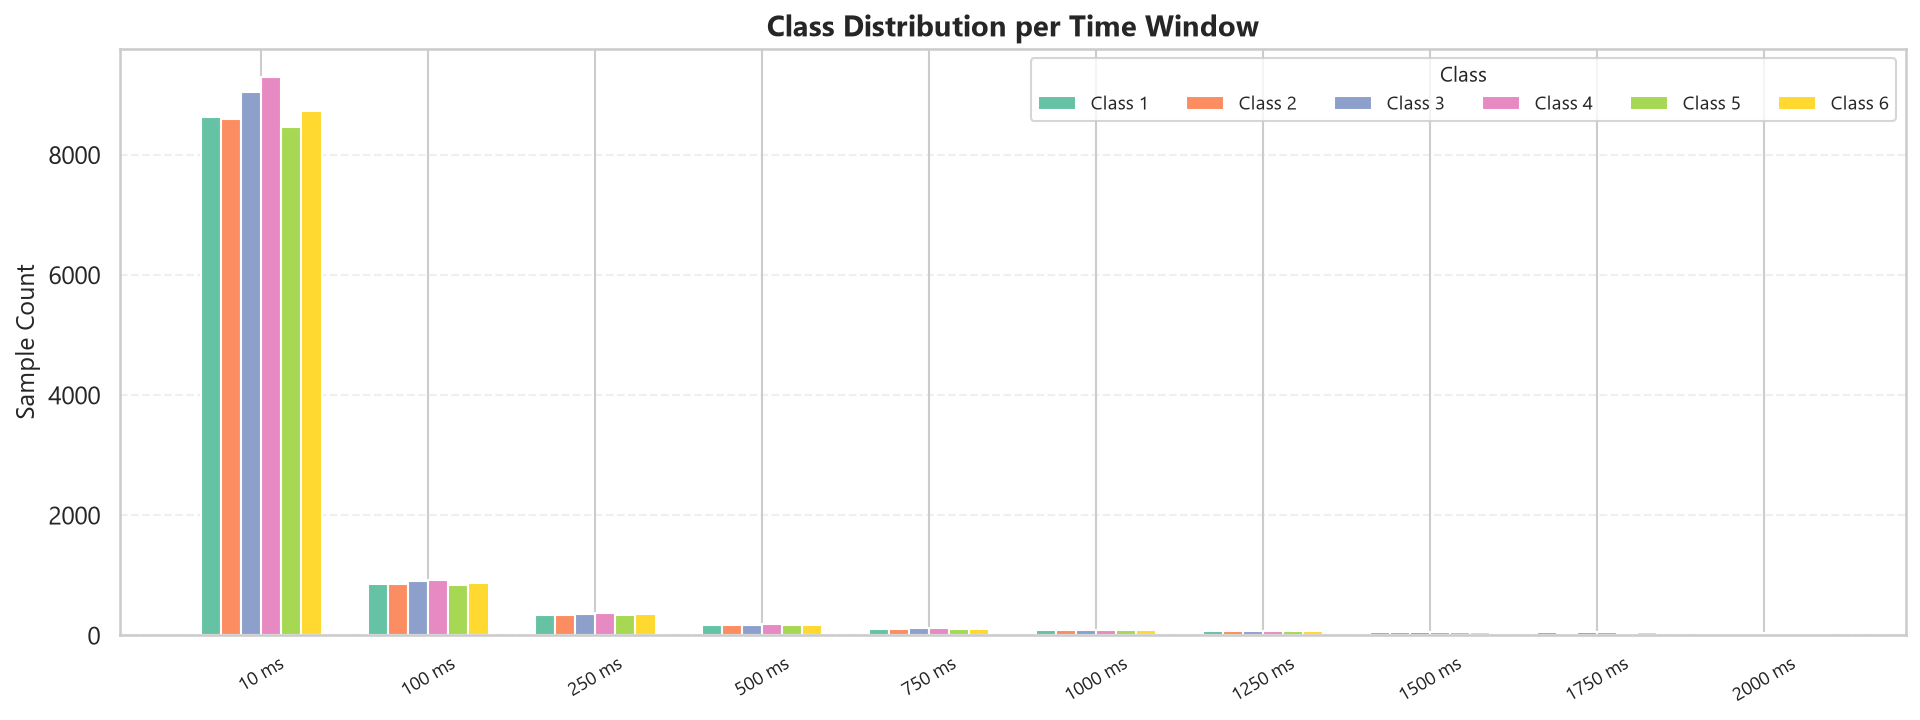

In [5]:
# Build a DataFrame with class counts per time window
rows = []
for tw, df in datasets.items():
    vc = df['label'].value_counts().sort_index()
    for cls, cnt in vc.items():
        rows.append({'time_window': tw, 'class': cls, 'count': cnt})
dist_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
classes = sorted(dist_df['class'].unique())
x = np.arange(len(datasets))
width = 0.12
palette = sns.color_palette("Set2", len(classes))

for i, cls in enumerate(classes):
    sub = dist_df[dist_df['class'] == cls]
    ax.bar(x + i * width, sub['count'].values, width,
           label=f"Class {cls}", color=palette[i], edgecolor='white')

ax.set_xticks(x + width * (len(classes) - 1) / 2)
ax.set_xticklabels([f"{tw} ms" for tw in datasets.keys()], fontsize=9, rotation=30)
ax.set_ylabel("Sample Count", fontsize=12)
ax.set_title("Class Distribution per Time Window", fontsize=14, fontweight='bold')
ax.legend(title="Class", fontsize=9, title_fontsize=10, ncol=len(classes))
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 4. Grid Search Training — All Time Windows

For each time window:
1. Run `GridSearchCV` (5-fold stratified CV)
2. Collect best accuracy, F1, and hyperparameters
3. Compute cross-validated predictions for confusion matrices

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = []

for tw, df in datasets.items():
    print(f"{'='*60}")
    print(f"  TIME WINDOW: {tw} ms   ({len(df):,} samples)")
    print(f"{'='*60}")

    X = df[NEURON_COLS].values
    y = df['label'].values

    grid = GridSearchCV(
        estimator=RandomForestClassifier(
            random_state=42, n_jobs=-1, class_weight='balanced'),
        param_grid=PARAM_GRID,
        cv=skf,
        scoring={'accuracy': 'accuracy', 'f1': 'f1_macro'},
        refit='accuracy',
        n_jobs=-1,
        return_train_score=False,
    )
    grid.fit(X, y)

    bp = grid.best_params_
    bi = grid.best_index_
    acc_mean = grid.cv_results_['mean_test_accuracy'][bi]
    acc_std  = grid.cv_results_['std_test_accuracy'][bi]
    f1_mean  = grid.cv_results_['mean_test_f1'][bi]
    f1_std   = grid.cv_results_['std_test_f1'][bi]

    # Cross-validated predictions
    best_model = grid.best_estimator_
    y_pred_cv = cross_val_predict(best_model, X, y, cv=skf, n_jobs=-1)

    depth_str = str(bp['max_depth']) if bp['max_depth'] is not None else 'None'
    print(f"  Best Acc : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Best F1  : {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"  Params   : n_est={bp['n_estimators']}, depth={depth_str}, "
          f"split={bp['min_samples_split']}, leaf={bp['min_samples_leaf']}")
    print()

    all_results.append({
        'time_window': tw,
        'accuracy': acc_mean,
        'acc_std': acc_std,
        'f1_macro': f1_mean,
        'f1_std': f1_std,
        'n_samples': len(df),
        'n_classes': len(np.unique(y)),
        'best_params': bp,
        'y_true': y,
        'y_pred': y_pred_cv,
        'model': best_model,
        'X': X,
    })

print(f"\n[OK] Training complete for {len(all_results)} time windows.")

  TIME WINDOW: 10 ms   (52,783 samples)
  Best Acc : 0.7151 ± 0.0035
  Best F1  : 0.6710 ± 0.0034
  Params   : n_est=100, depth=None, split=2, leaf=1

  TIME WINDOW: 100 ms   (5,279 samples)
  Best Acc : 0.8651 ± 0.0107
  Best F1  : 0.8611 ± 0.0128
  Params   : n_est=200, depth=10, split=5, leaf=1

  TIME WINDOW: 250 ms   (2,112 samples)
  Best Acc : 0.8707 ± 0.0154
  Best F1  : 0.8675 ± 0.0169
  Params   : n_est=200, depth=10, split=5, leaf=2

  TIME WINDOW: 500 ms   (1,056 samples)
  Best Acc : 0.8760 ± 0.0300
  Best F1  : 0.8739 ± 0.0329
  Params   : n_est=200, depth=10, split=5, leaf=2

  TIME WINDOW: 750 ms   (704 samples)
  Best Acc : 0.8637 ± 0.0339
  Best F1  : 0.8618 ± 0.0386
  Params   : n_est=50, depth=None, split=2, leaf=2

  TIME WINDOW: 1000 ms   (528 samples)
  Best Acc : 0.8845 ± 0.0067
  Best F1  : 0.8848 ± 0.0081
  Params   : n_est=50, depth=None, split=5, leaf=2

  TIME WINDOW: 1250 ms   (423 samples)
  Best Acc : 0.8864 ± 0.0223
  Best F1  : 0.8869 ± 0.0231
  Params

## 5. Results Summary Table

In [7]:
summary_rows = []
for r in all_results:
    bp = r['best_params']
    summary_rows.append({
        'TW (ms)': r['time_window'],
        'Samples': r['n_samples'],
        'Classes': r['n_classes'],
        'Accuracy': f"{r['accuracy']:.4f}",
        '± Std': f"{r['acc_std']:.4f}",
        'F1 Macro': f"{r['f1_macro']:.4f}",
        'n_estimators': bp['n_estimators'],
        'max_depth': bp['max_depth'],
        'min_samples_split': bp['min_samples_split'],
        'min_samples_leaf': bp['min_samples_leaf'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_caption("Grid Search Results per Time Window")

,TW (ms),Samples,Classes,Accuracy,± Std,F1 Macro,n_estimators,max_depth,min_samples_split,min_samples_leaf
0,10,52783,6,0.7151,0.0035,0.6710,100,nan,2,1
1,100,5279,6,0.8651,0.0107,0.8611,200,10.000000,5,1
2,250,2112,6,0.8707,0.0154,0.8675,200,10.000000,5,2
3,500,1056,6,0.8760,0.0300,0.8739,200,10.000000,5,2
4,750,704,6,0.8637,0.0339,0.8618,50,nan,2,2
5,1000,528,6,0.8845,0.0067,0.8848,50,nan,5,2
6,1250,423,6,0.8864,0.0223,0.8869,100,10.000000,5,1
7,1500,352,6,0.8780,0.0420,0.8807,200,nan,2,2
8,1750,302,6,0.8775,0.0270,0.8755,100,nan,5,2
9,2000,264,6,0.8710,0.0232,0.8732,200,nan,2,2


## 6. Confusion Matrices (per Time Window)

Each confusion matrix shows **absolute counts** on the left and **row-normalized percentages** on the right.

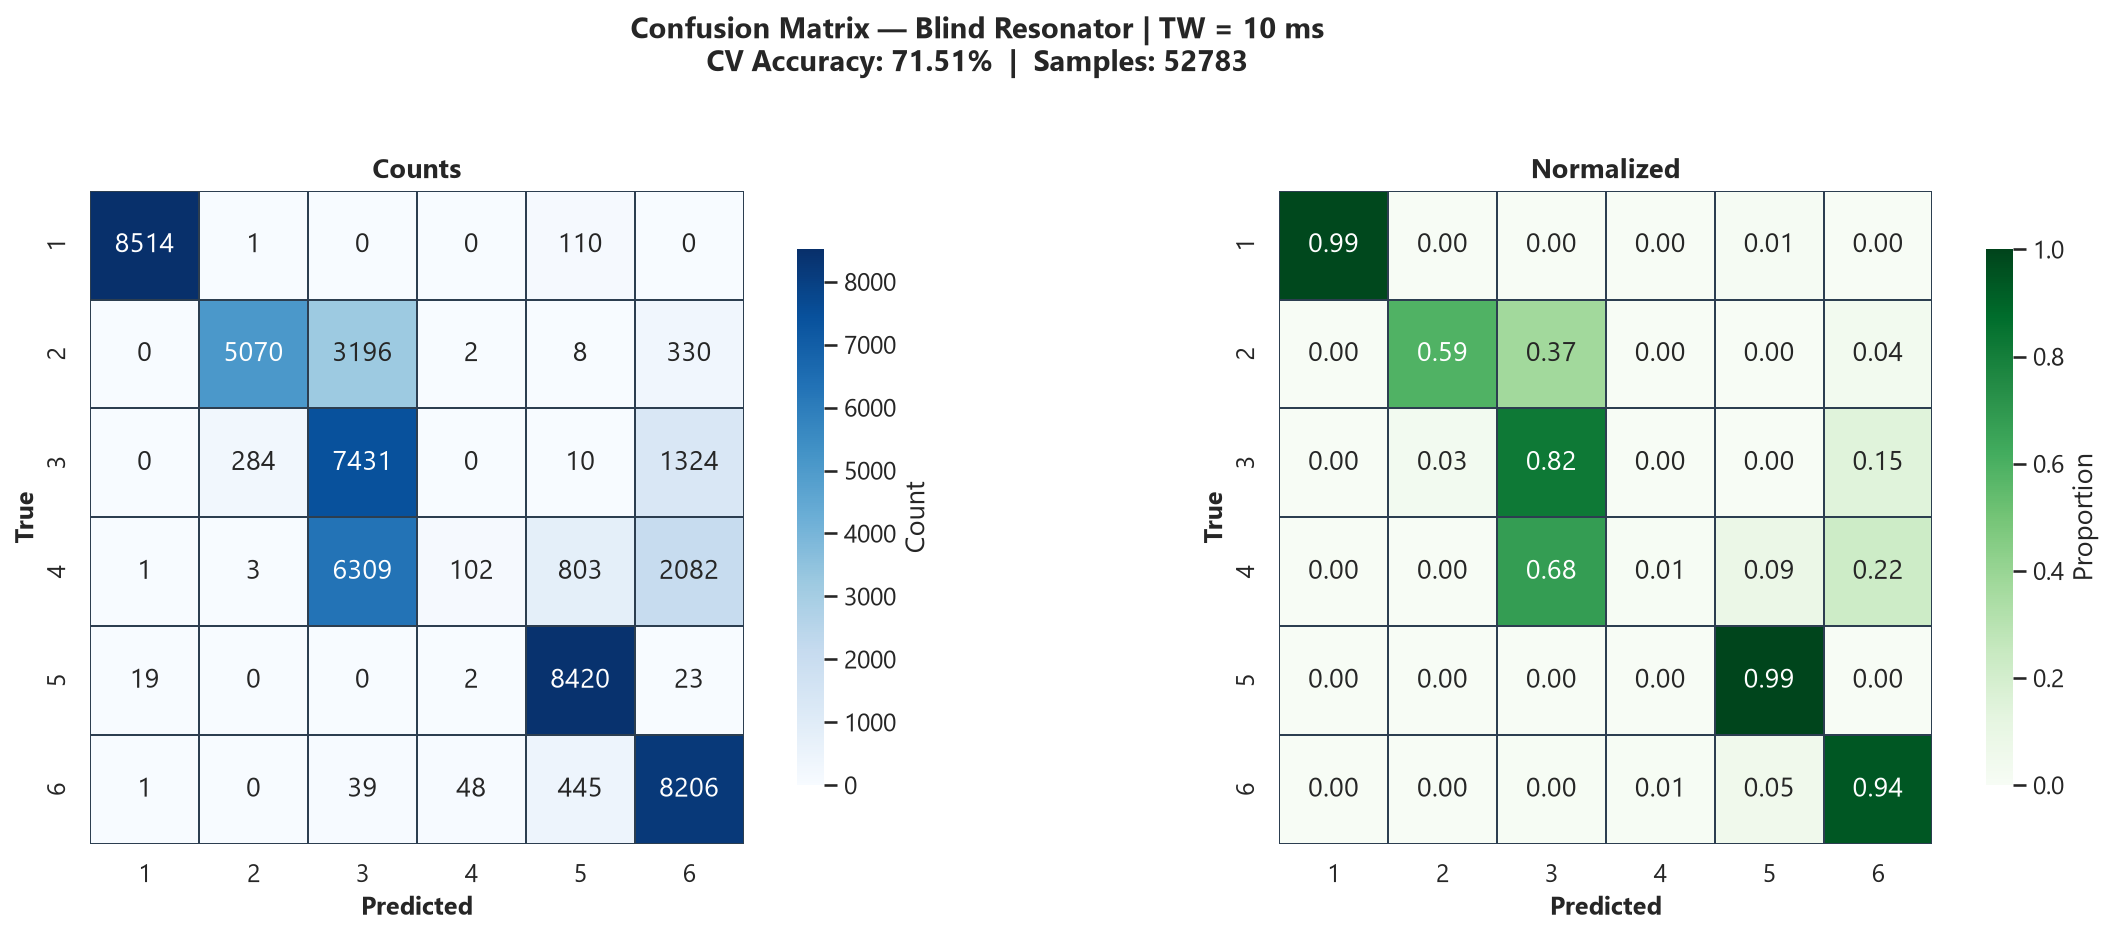

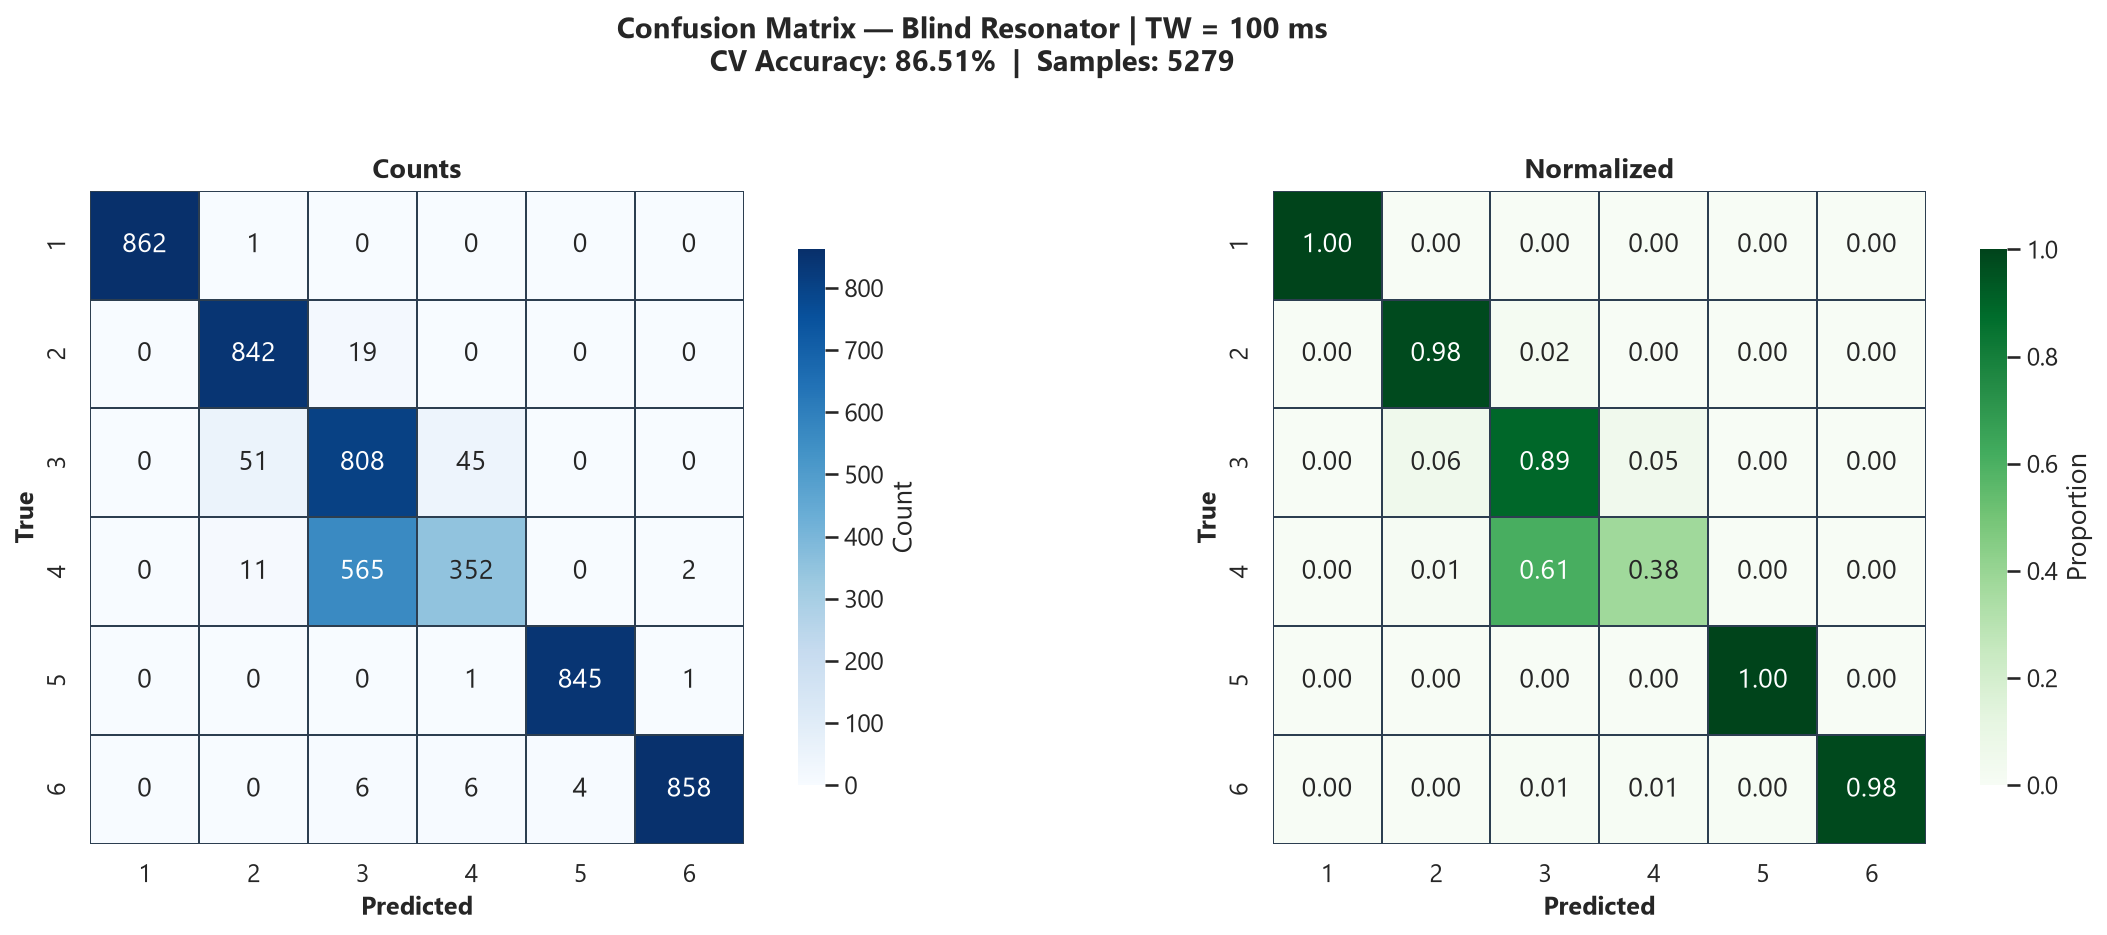

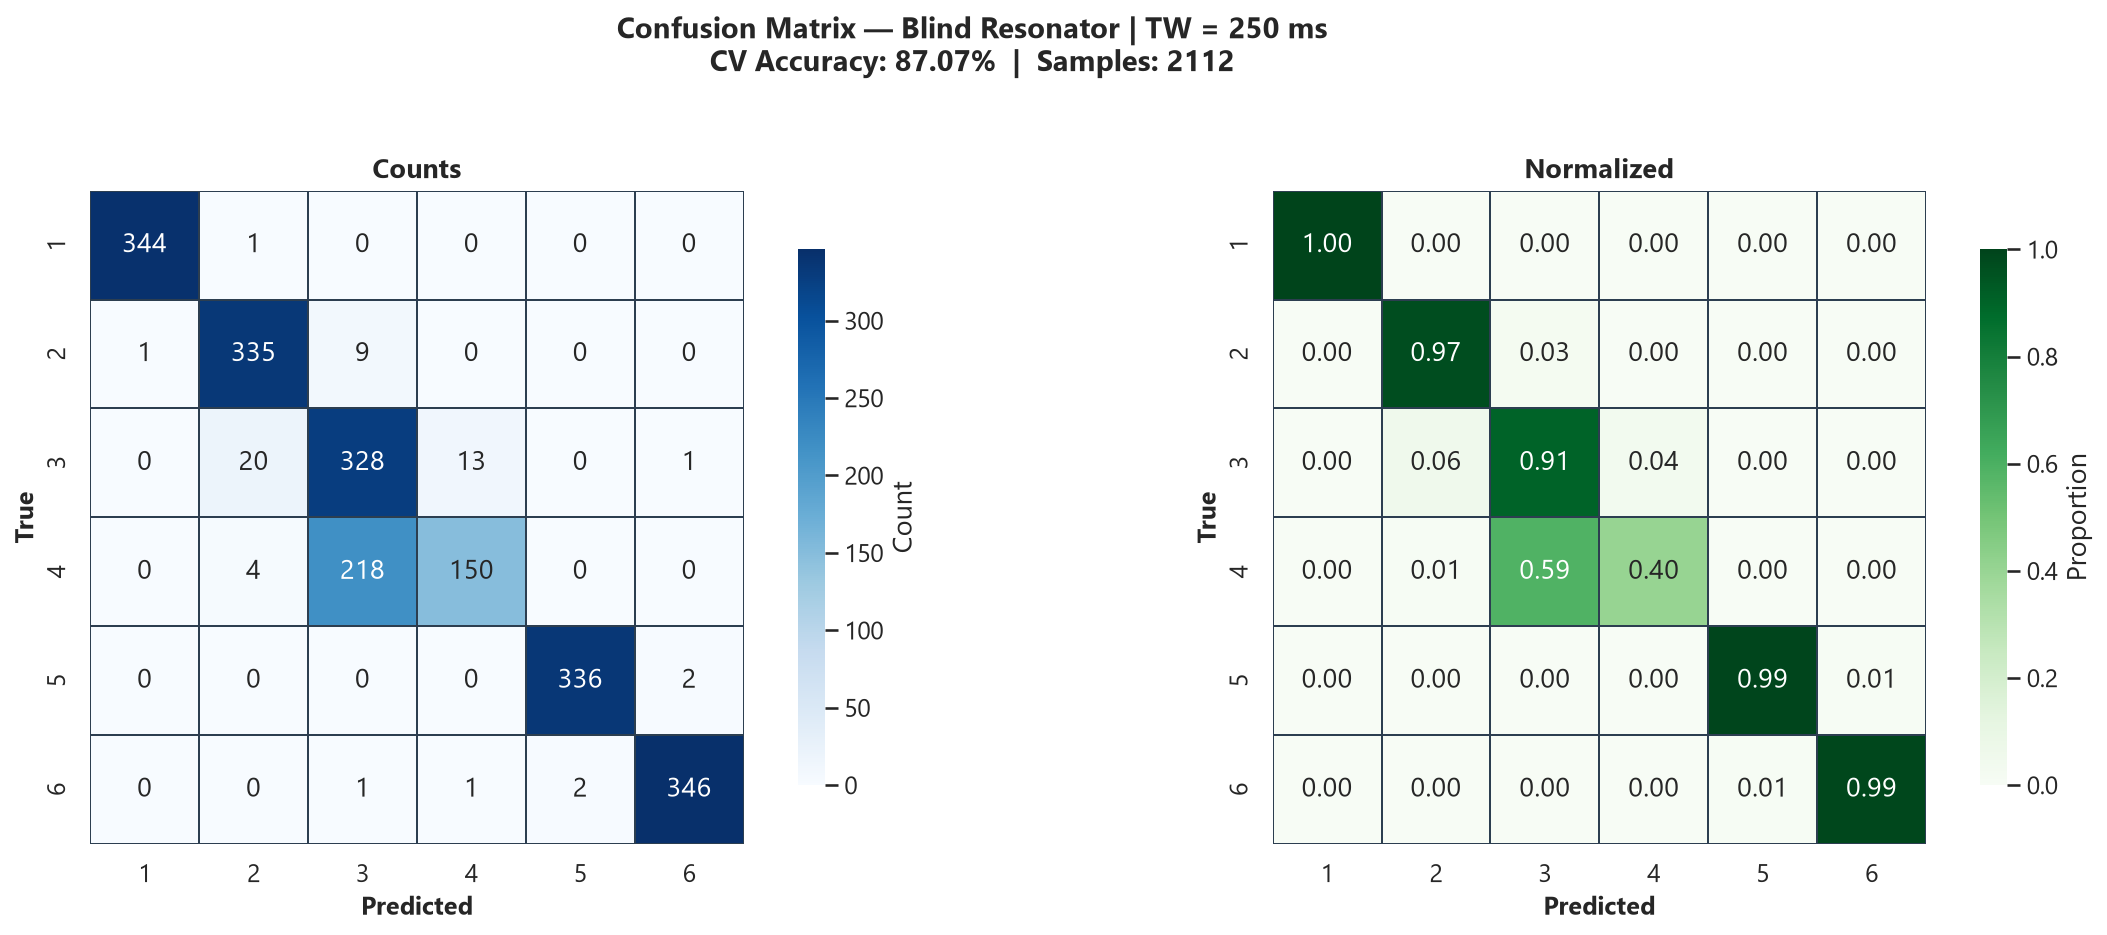

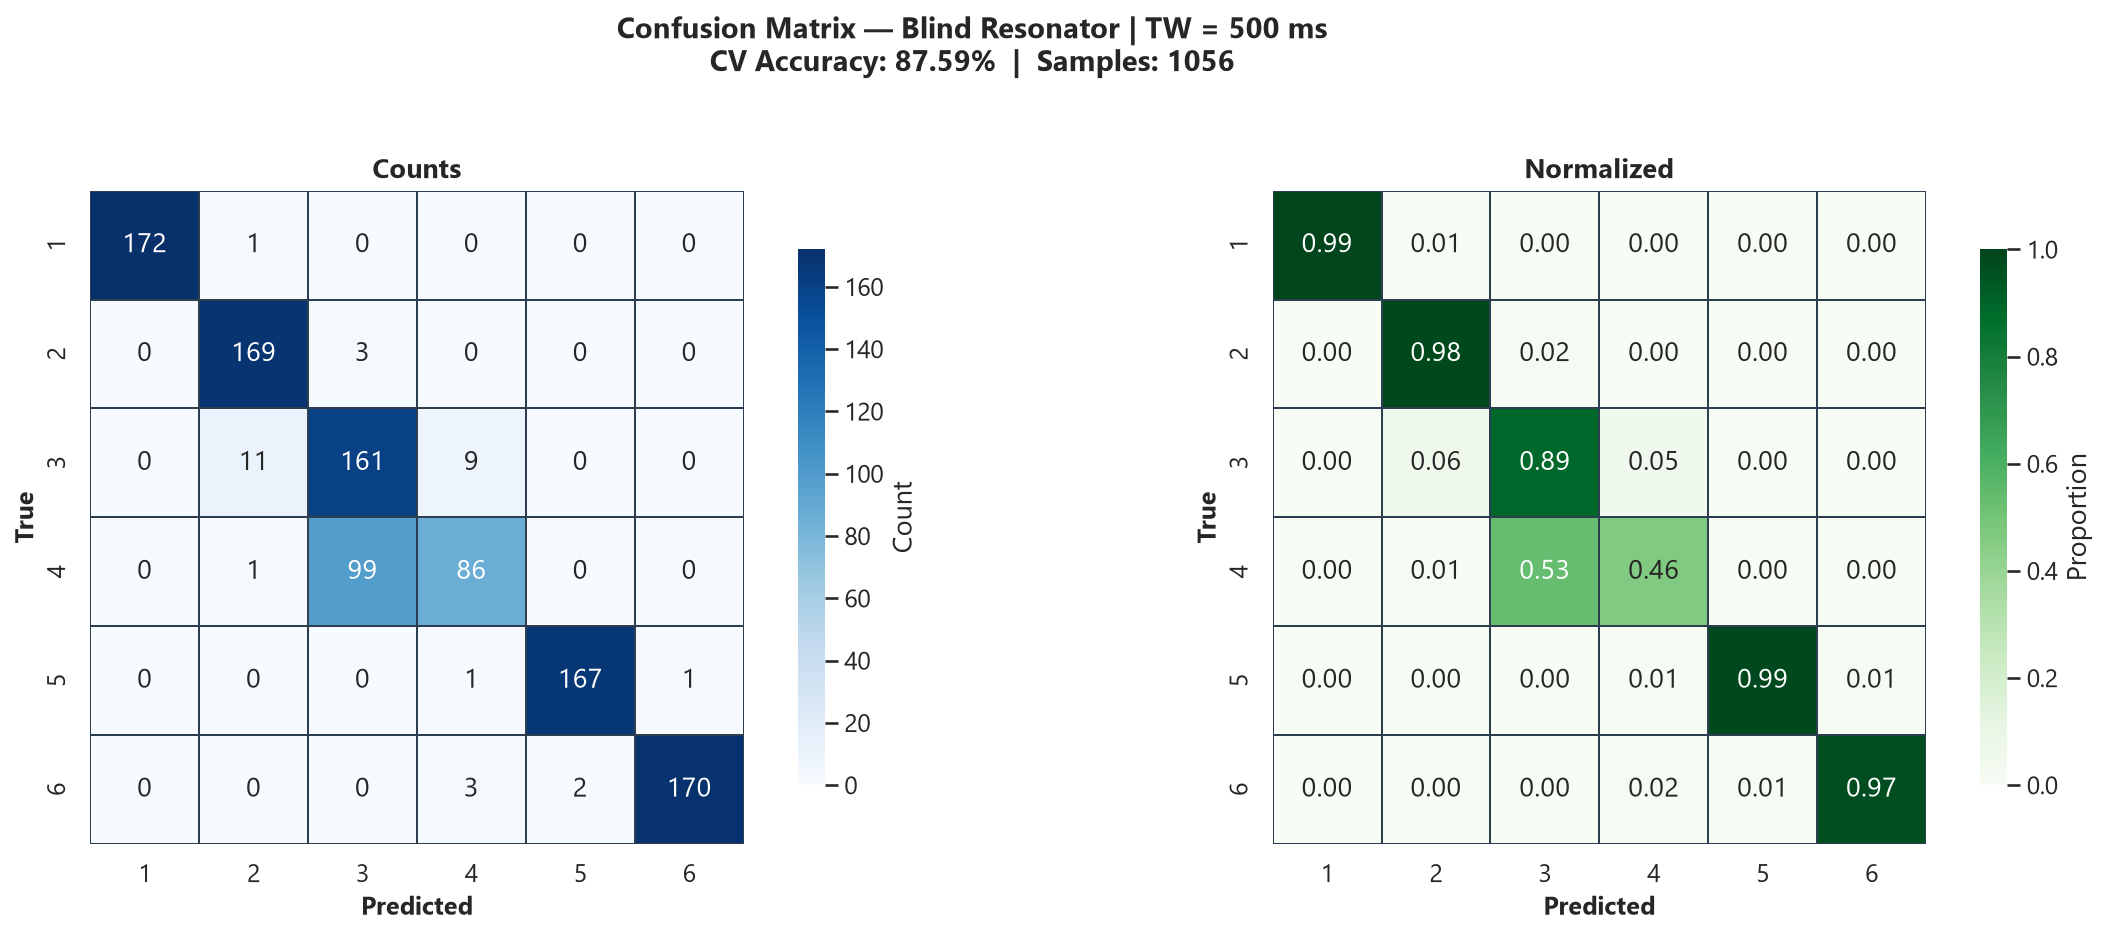

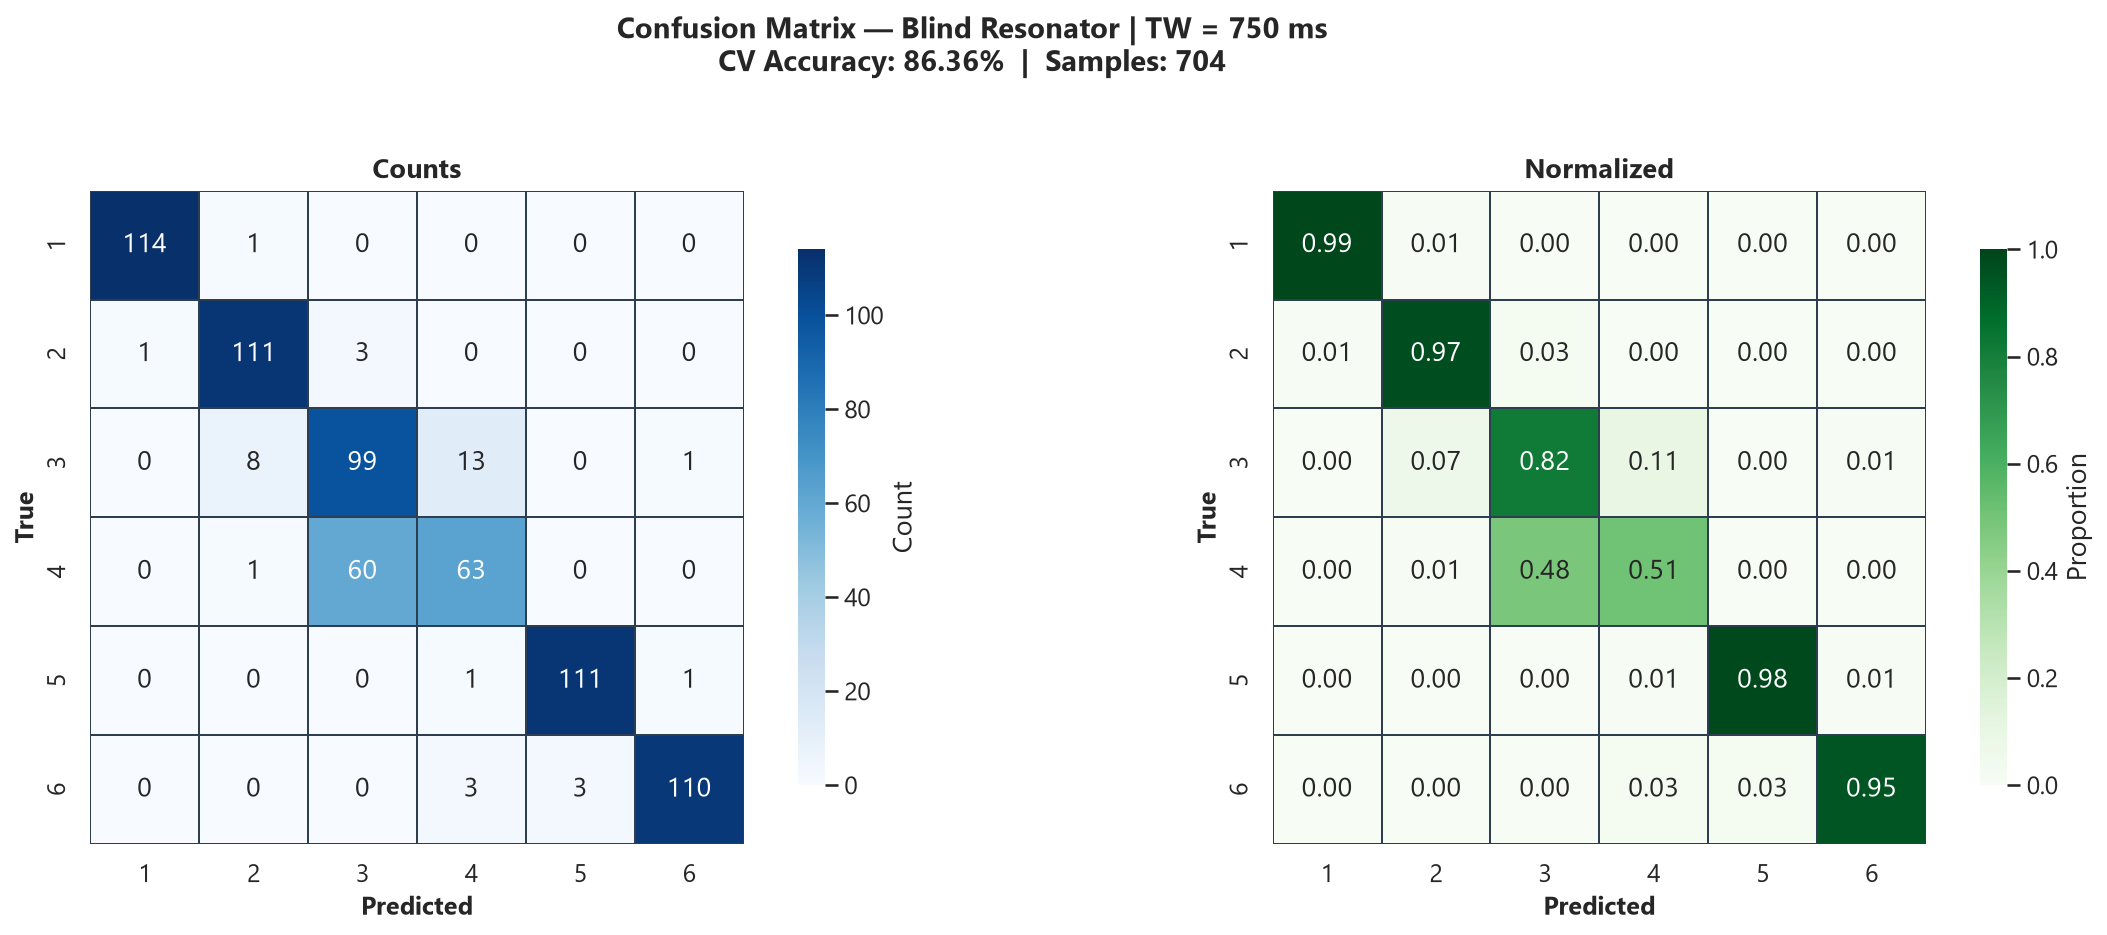

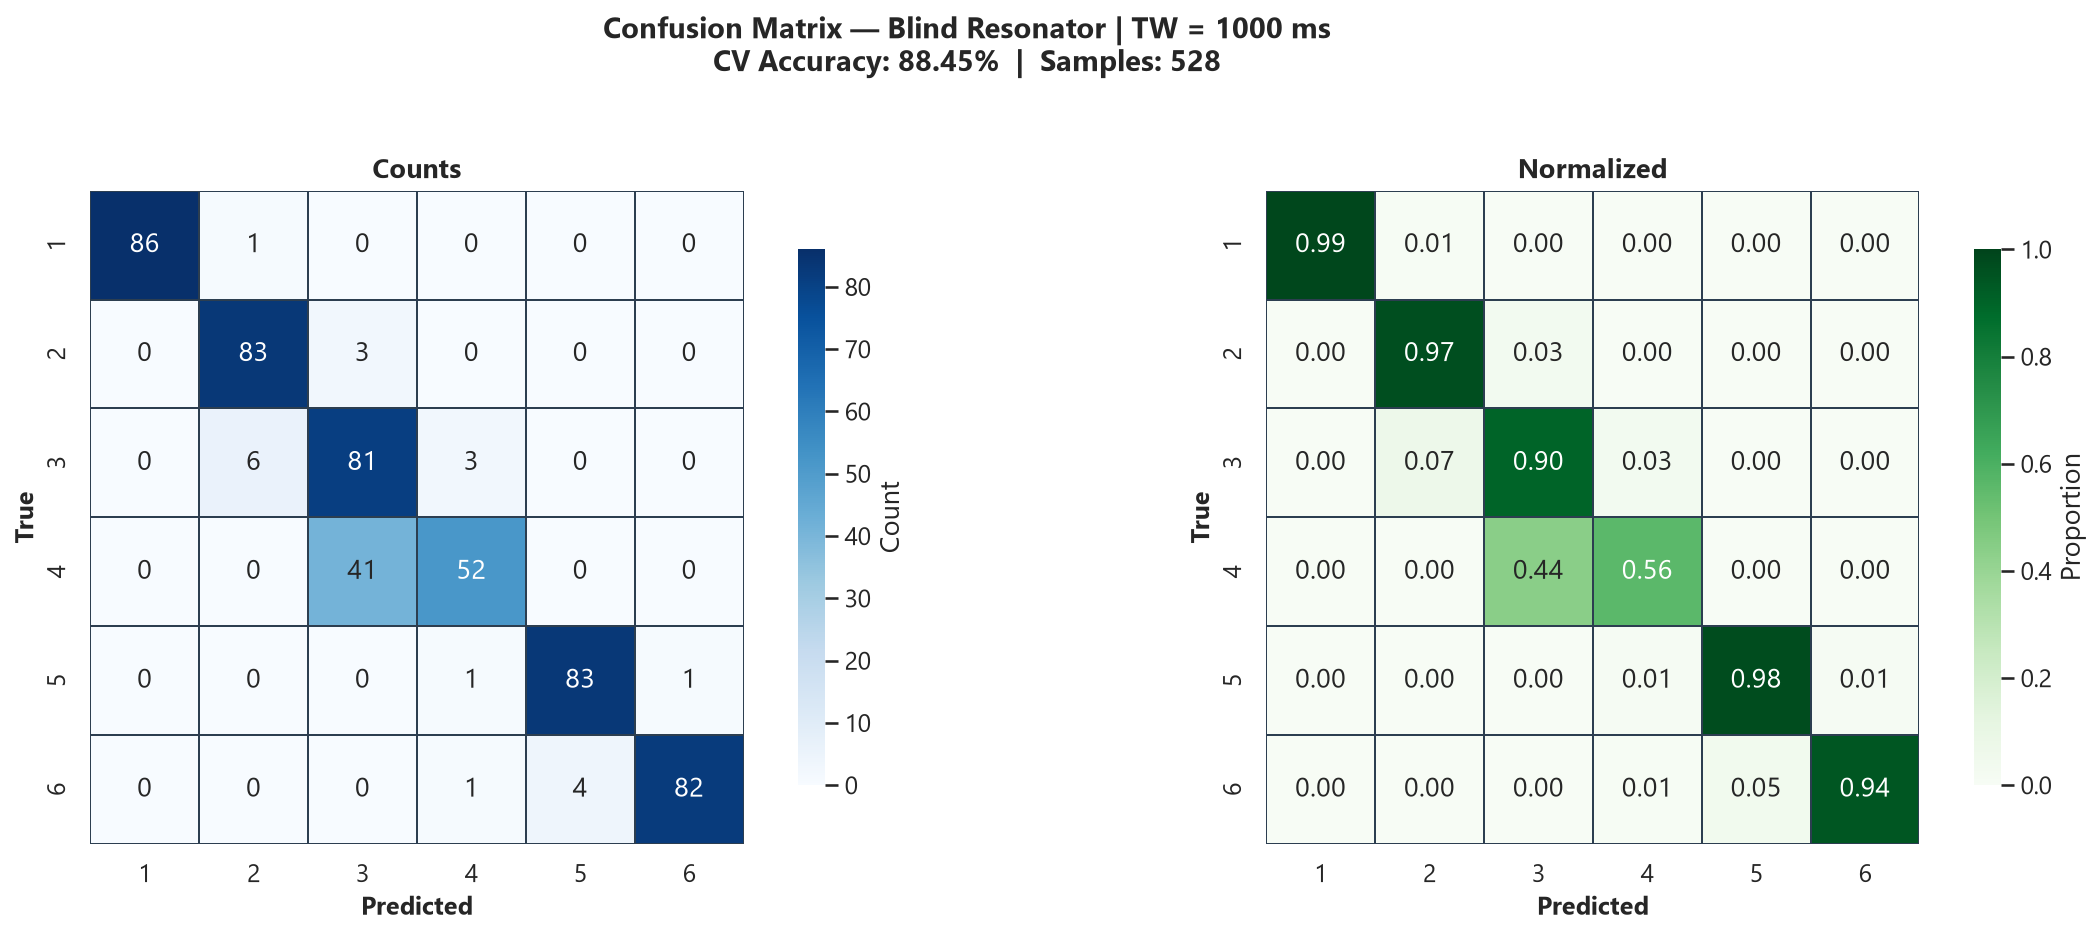

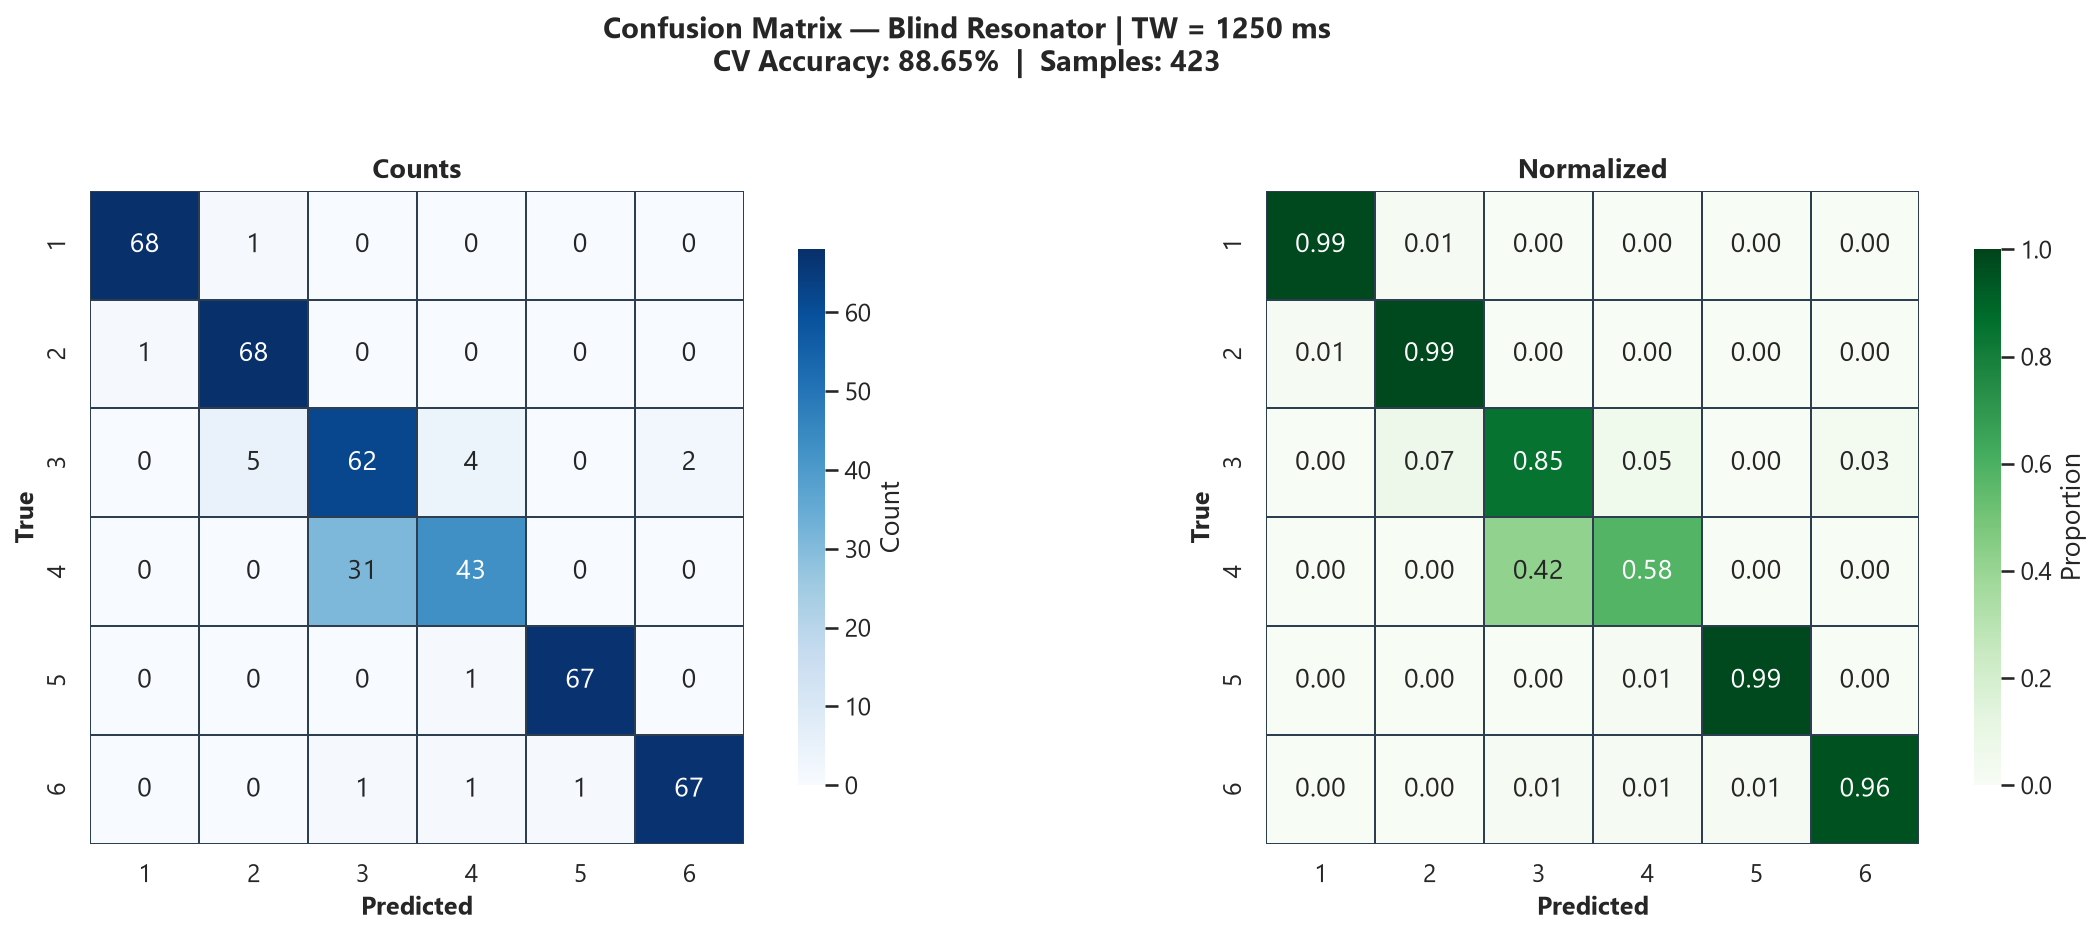

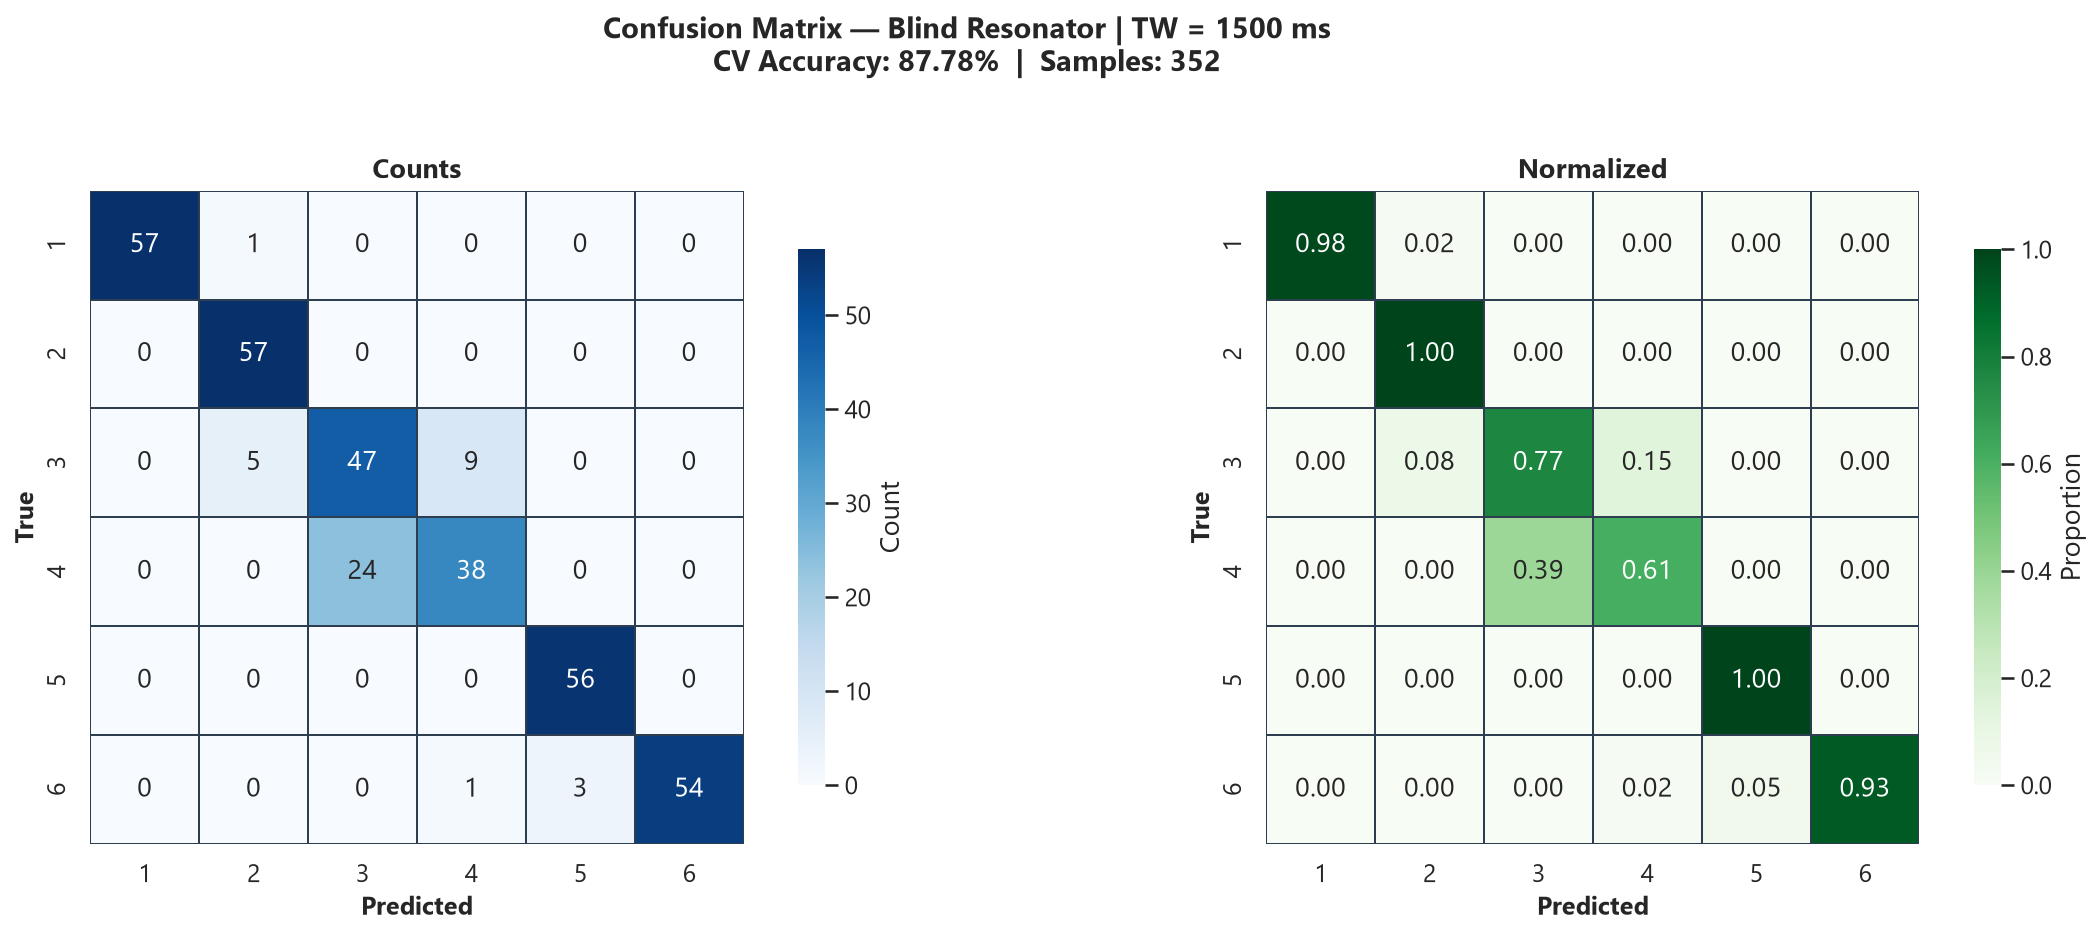

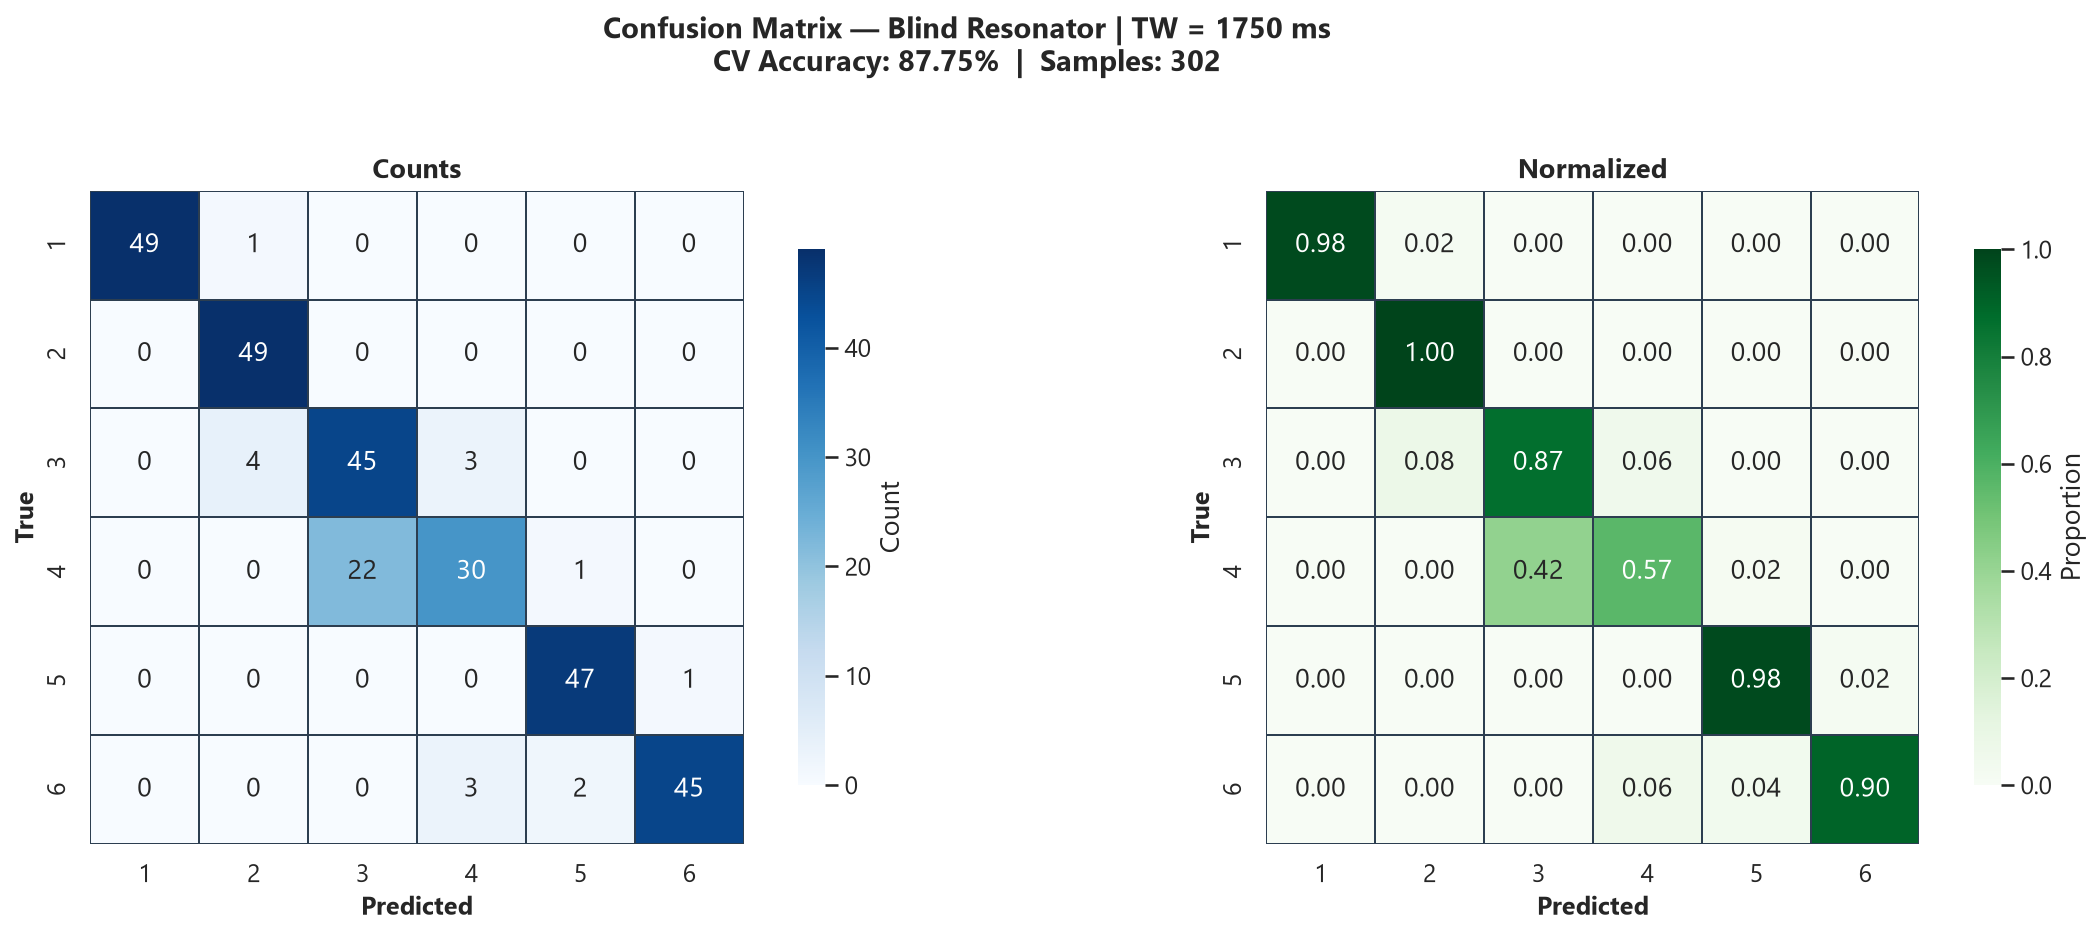

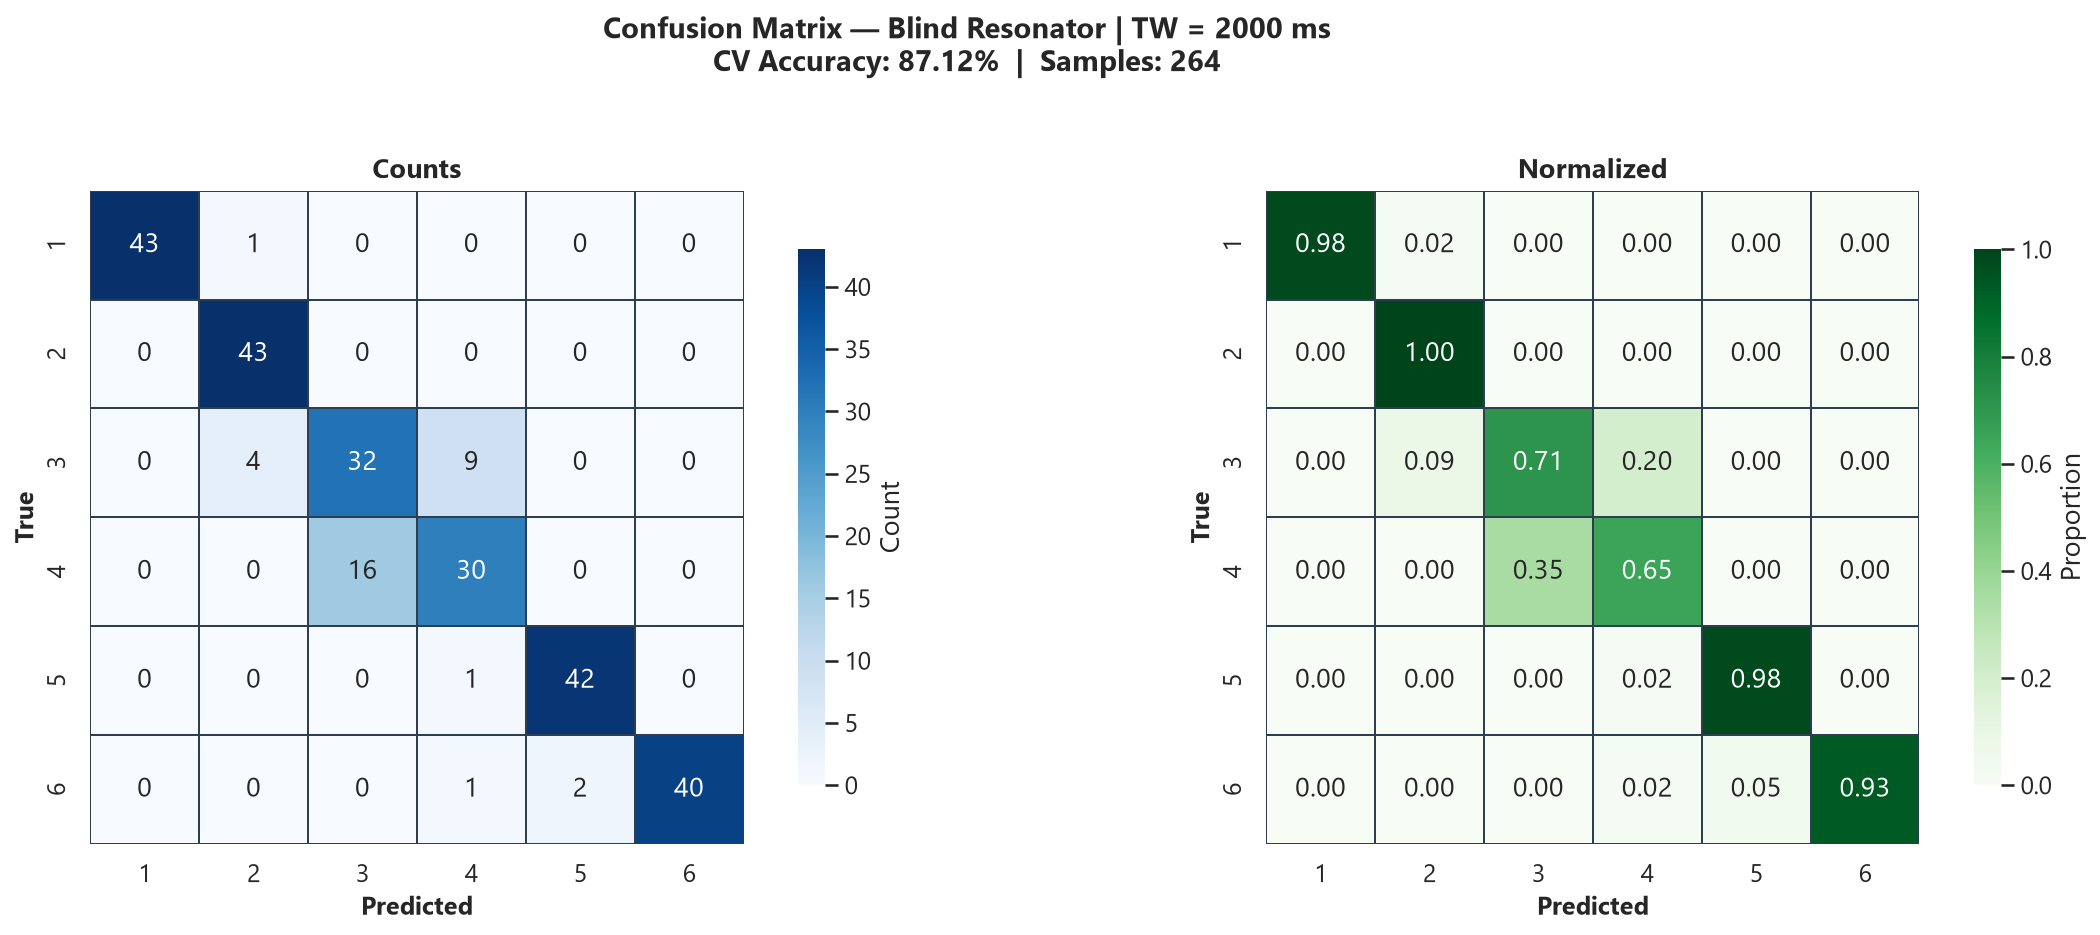

In [8]:
for r in all_results:
    tw = r['time_window']
    y_true = r['y_true']
    y_pred = r['y_pred']
    labels = sorted(set(y_true) | set(y_pred))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Absolute counts ---
    annot_abs = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot_abs[i, j] = f"{cm[i, j]}"

    sns.heatmap(cm, annot=annot_abs, fmt='', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.8, linecolor='#2c3e50',
                cbar_kws={'label': 'Count', 'shrink': 0.82},
                square=True, ax=axes[0])
    axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
    axes[0].set_title('Counts', fontsize=13, fontweight='bold')

    # --- Normalized ---
    annot_norm = np.empty_like(cm_norm, dtype=object)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            annot_norm[i, j] = f"{cm_norm[i, j]:.2f}"

    sns.heatmap(cm_norm, annot=annot_norm, fmt='', cmap='Greens',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.8, linecolor='#2c3e50',
                vmin=0, vmax=1,
                cbar_kws={'label': 'Proportion', 'shrink': 0.82},
                square=True, ax=axes[1])
    axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
    axes[1].set_title('Normalized', fontsize=13, fontweight='bold')

    acc_cv = accuracy_score(y_true, y_pred)
    fig.suptitle(
        f"Confusion Matrix — Blind Resonator | TW = {tw} ms\n"
        f"CV Accuracy: {acc_cv*100:.2f}%  |  Samples: {len(y_true)}",
        fontsize=14, fontweight='bold', y=1.03)

    plt.tight_layout()
    plt.show()

## 7. Classification Reports

Per-class precision, recall, and F1 for each time window.

In [9]:
for r in all_results:
    tw = r['time_window']
    y_true = r['y_true']
    y_pred = r['y_pred']
    labels = sorted(set(y_true) | set(y_pred))

    print(f"{'='*60}")
    print(f"  Classification Report — TW = {tw} ms")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, labels=labels,
                                target_names=[f"Class {c}" for c in labels]))
    print()

  Classification Report — TW = 10 ms
              precision    recall  f1-score   support

     Class 1       1.00      0.99      0.99      8625
     Class 2       0.95      0.59      0.73      8606
     Class 3       0.44      0.82      0.57      9049
     Class 4       0.66      0.01      0.02      9300
     Class 5       0.86      0.99      0.92      8464
     Class 6       0.69      0.94      0.79      8739

    accuracy                           0.72     52783
   macro avg       0.76      0.72      0.67     52783
weighted avg       0.76      0.72      0.66     52783


  Classification Report — TW = 100 ms
              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00       863
     Class 2       0.93      0.98      0.95       861
     Class 3       0.58      0.89      0.70       904
     Class 4       0.87      0.38      0.53       930
     Class 5       1.00      1.00      1.00       847
     Class 6       1.00      0.98      0.99       874

 

## 8. Feature Importance per Time Window

How much each neuron channel contributes to the classification decision, visualised as a grouped bar chart across all time windows.

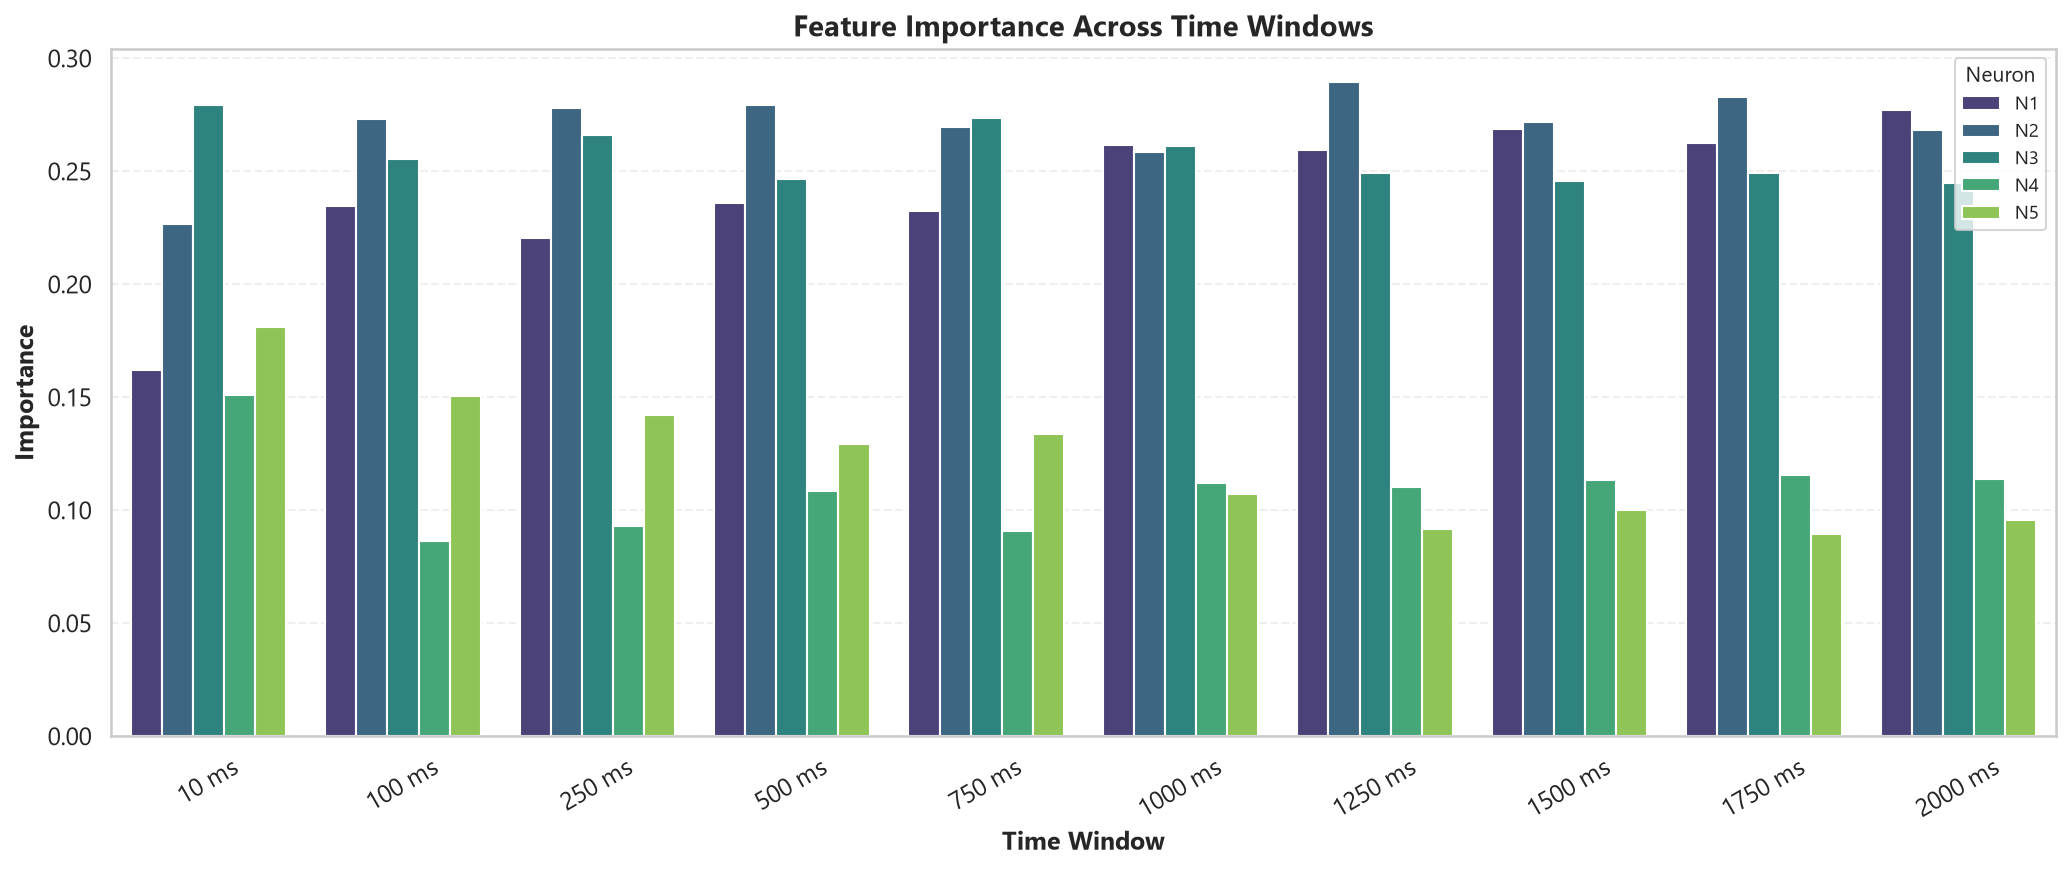

In [10]:
# Collect importances into a DataFrame
imp_rows = []
for r in all_results:
    model = r['model']
    for feat, imp in zip(NEURON_COLS, model.feature_importances_):
        imp_rows.append({
            'time_window': f"{r['time_window']} ms",
            'feature': feat,
            'importance': imp,
        })
imp_df = pd.DataFrame(imp_rows)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=imp_df, x='time_window', y='importance', hue='feature',
            palette='viridis', edgecolor='white', ax=ax)
ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Across Time Windows', fontsize=14, fontweight='bold')
ax.legend(title='Neuron', fontsize=9, title_fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Accuracy vs Time Window

Summary plot showing how accuracy evolves as the time window increases, with smooth spline interpolation.

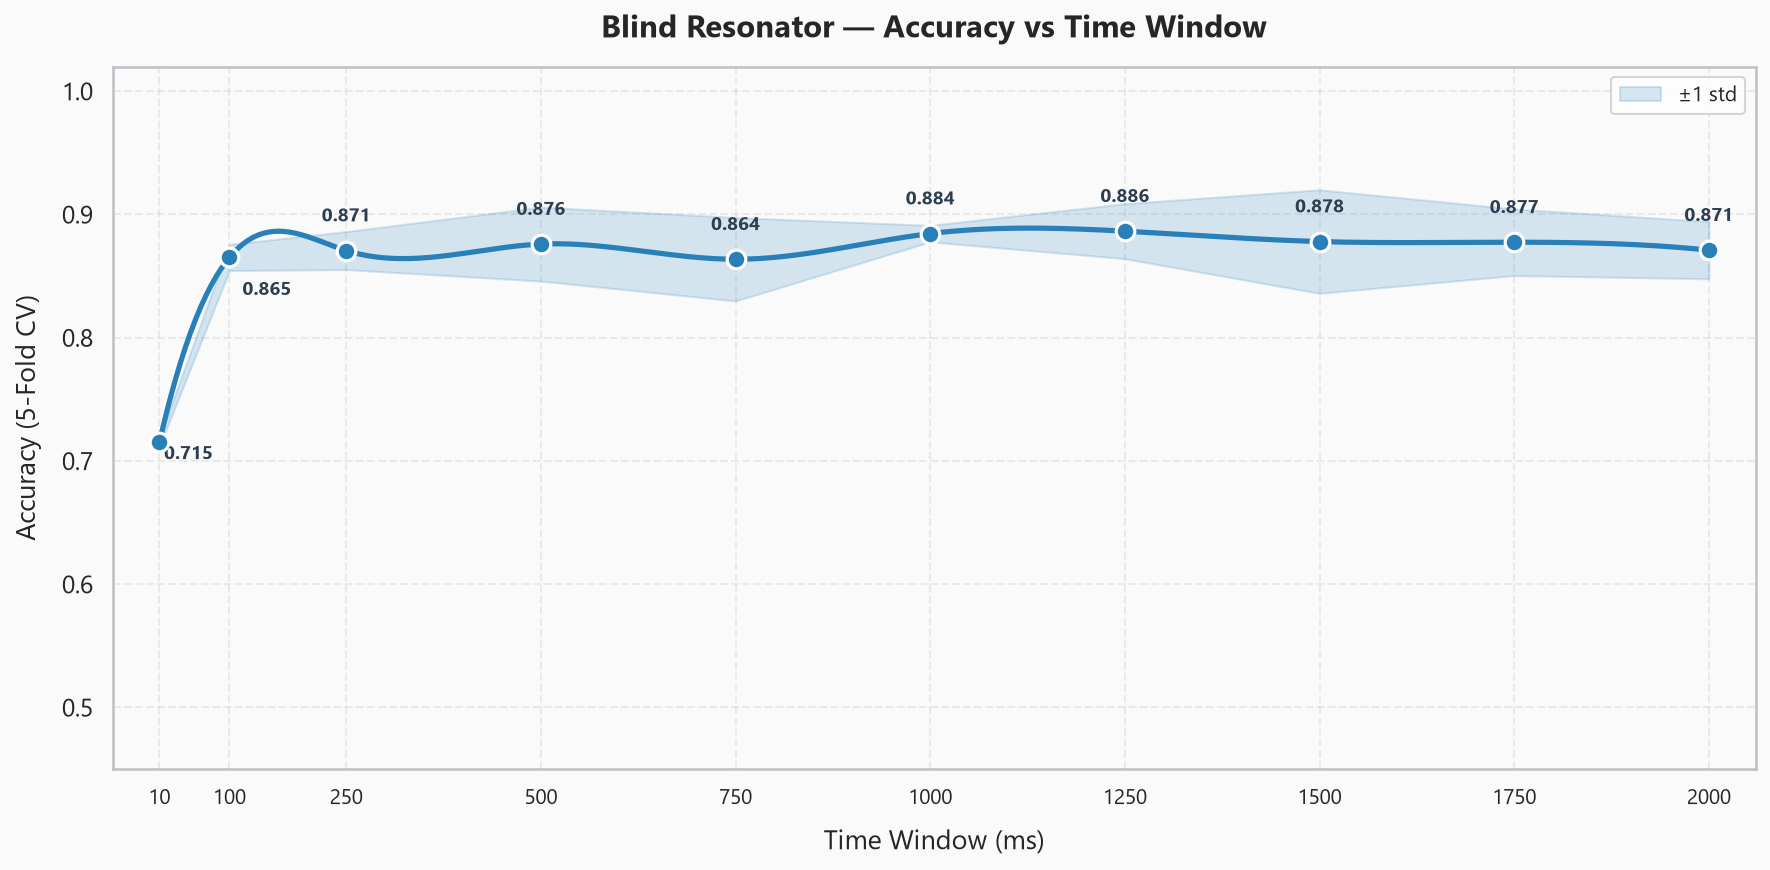

In [11]:
tw_arr  = np.array([r['time_window'] for r in all_results], dtype=float)
acc_arr = np.array([r['accuracy']    for r in all_results])
std_arr = np.array([r['acc_std']     for r in all_results])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# Smooth spline
tw_smooth = np.linspace(tw_arr.min(), tw_arr.max(), 300)
try:
    spl = make_interp_spline(tw_arr, acc_arr, k=3)
    acc_smooth = spl(tw_smooth)
except Exception:
    acc_smooth = np.interp(tw_smooth, tw_arr, acc_arr)

# Confidence band (±1 std)
ax.fill_between(tw_arr, acc_arr - std_arr, acc_arr + std_arr,
                alpha=0.18, color='#2980b9', label='±1 std')

# Interpolated curve
ax.plot(tw_smooth, acc_smooth, color='#2980b9', linewidth=2.5, zorder=3)

# Data-point markers
ax.scatter(tw_arr, acc_arr, s=80, color='#2980b9', edgecolors='white',
           linewidths=1.5, zorder=4)

# Annotate each point
for x, y in zip(tw_arr, acc_arr):
    ofs = (0, 14)
    if x == 10:
        ofs = (14, -8)
    elif x == 100:
        ofs = (18, -18)
    ax.annotate(f'{y:.3f}', (x, y),
                textcoords='offset points', xytext=ofs,
                ha='center', fontsize=9, fontweight='bold',
                color='#2c3e50')

ax.set_xlabel('Time Window (ms)', fontsize=13, labelpad=10)
ax.set_ylabel('Accuracy (5-Fold CV)', fontsize=13, labelpad=10)
ax.set_title('Blind Resonator — Accuracy vs Time Window',
             fontsize=15, fontweight='bold', pad=14)

ax.set_xticks(tw_arr)
ax.set_xticklabels([f'{int(t)}' for t in tw_arr], fontsize=10)
ax.set_ylim(0.45, 1.02)
ax.set_xlim(tw_arr.min() - 60, tw_arr.max() + 60)
ax.legend(fontsize=10)

ax.grid(True, alpha=0.35, linestyle='--')
for spine in ax.spines.values():
    spine.set_color('#bdc3c7')

plt.tight_layout()
plt.show()

## 10. F1 Macro vs Time Window

Parallel view comparing F1 macro scores across time windows.

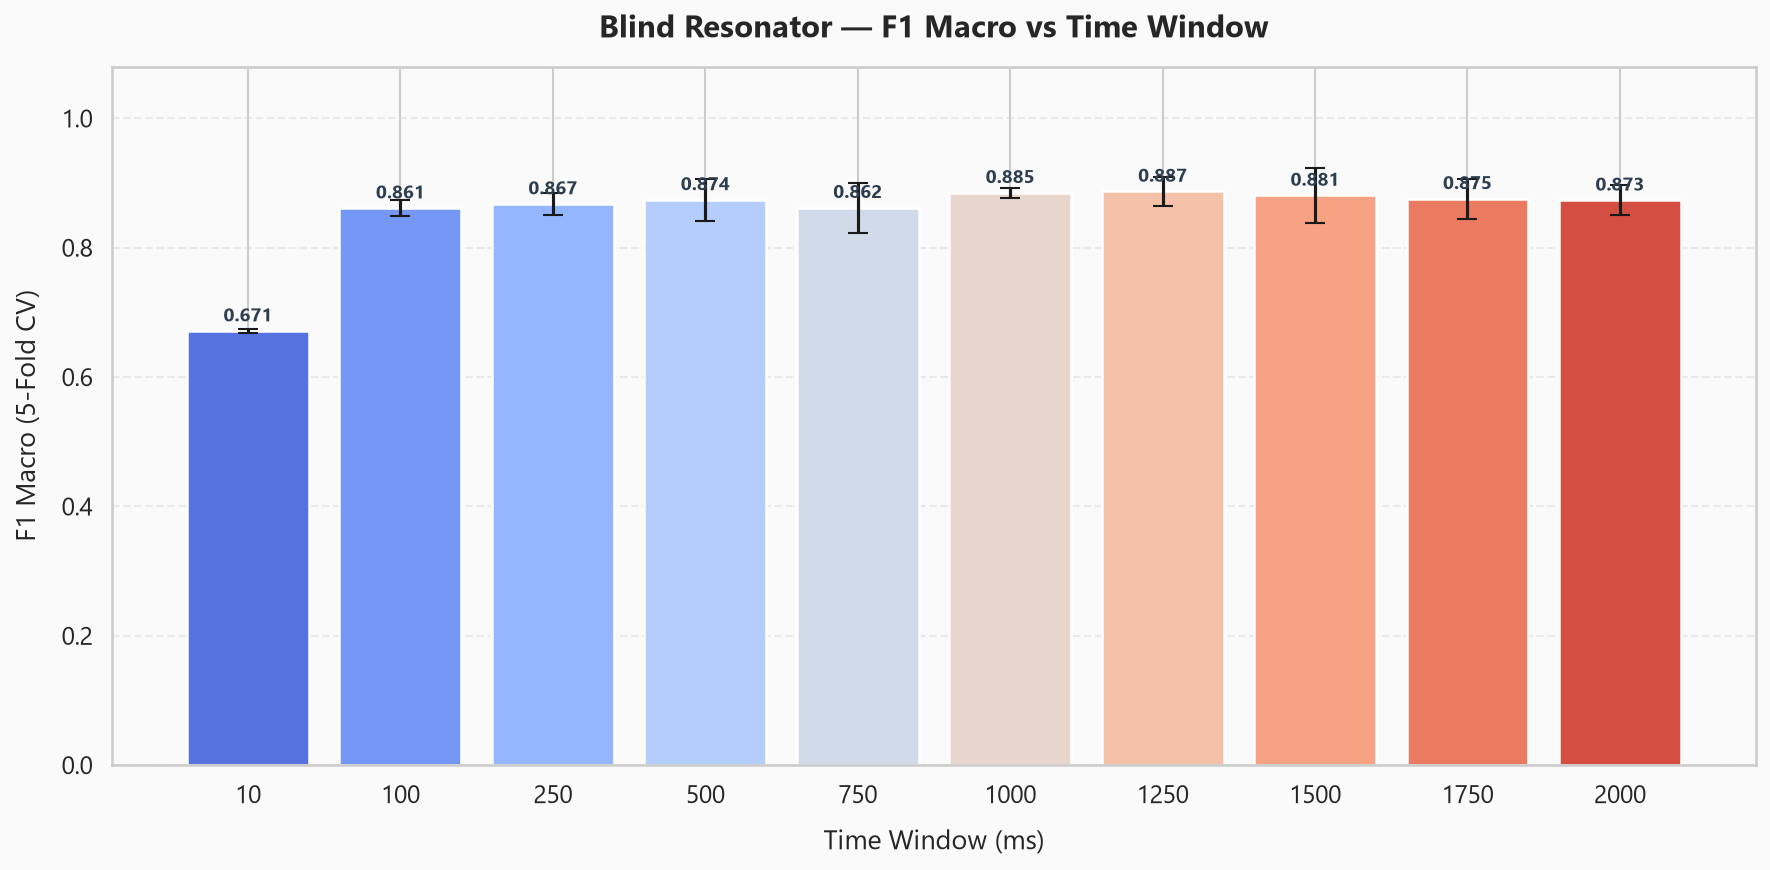

In [12]:
f1_arr  = np.array([r['f1_macro'] for r in all_results])
f1_std  = np.array([r['f1_std']   for r in all_results])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# Bar chart with error bars
colors = sns.color_palette("coolwarm", len(all_results))
bars = ax.bar([f"{int(t)}" for t in tw_arr], f1_arr,
              yerr=f1_std, capsize=5, color=colors, edgecolor='white',
              linewidth=1.2)

# Value labels on top of bars
for bar, val in zip(bars, f1_arr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{val:.3f}", ha='center', fontsize=9, fontweight='bold',
            color='#2c3e50')

ax.set_xlabel('Time Window (ms)', fontsize=13, labelpad=10)
ax.set_ylabel('F1 Macro (5-Fold CV)', fontsize=13, labelpad=10)
ax.set_title('Blind Resonator — F1 Macro vs Time Window',
             fontsize=15, fontweight='bold', pad=14)
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

## 11. Per-Class F1 Score Heatmap

Detailed view of which classes are easy/hard to classify at each time window.

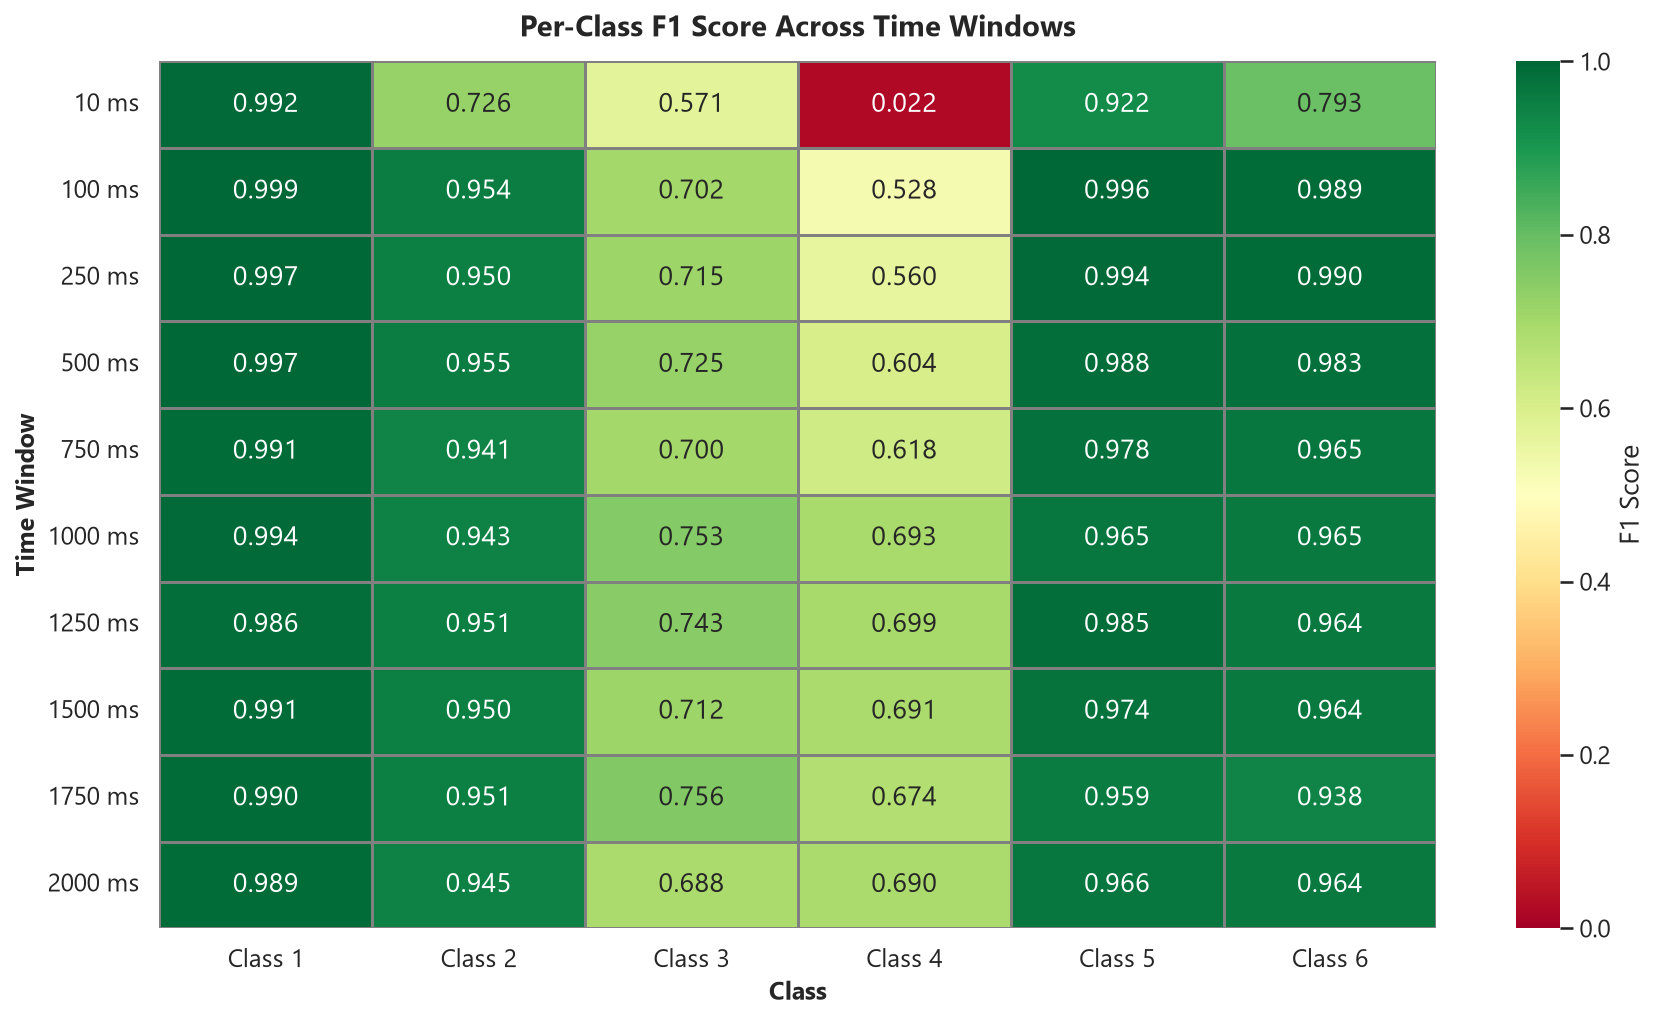

In [13]:
from sklearn.metrics import f1_score as f1_score_fn

# Build per-class F1 matrix
all_classes = sorted(set(c for r in all_results for c in np.unique(r['y_true'])))
f1_matrix = []

for r in all_results:
    labels = sorted(set(r['y_true']) | set(r['y_pred']))
    per_class = f1_score_fn(r['y_true'], r['y_pred'], labels=labels,
                            average=None, zero_division=0)
    row = {}
    for cls, score in zip(labels, per_class):
        row[f"Class {cls}"] = score
    # Fill missing classes with NaN
    for cls in all_classes:
        if f"Class {cls}" not in row:
            row[f"Class {cls}"] = np.nan
    f1_matrix.append(row)

f1_heatmap_df = pd.DataFrame(f1_matrix, index=[f"{r['time_window']} ms" for r in all_results])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(f1_heatmap_df.astype(float), annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'F1 Score'},
            ax=ax)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Window', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Score Across Time Windows',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 12. Accuracy & F1 Macro — Combined View

Direct comparison of accuracy and F1 macro across time windows.

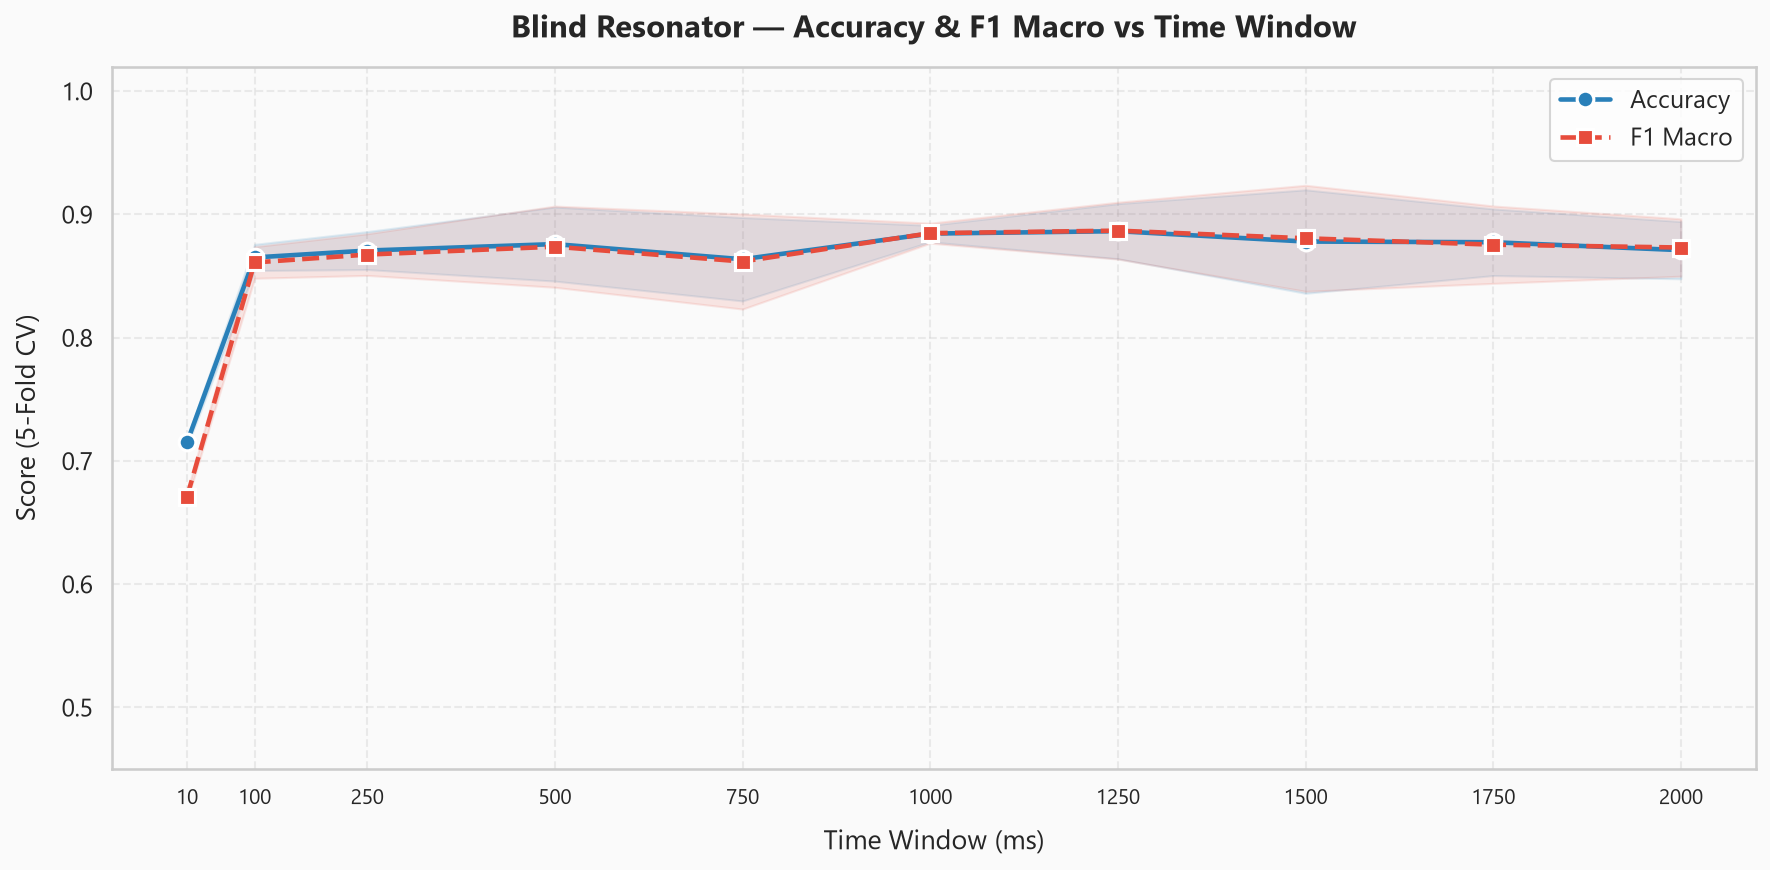

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# Plot both metrics
ax.plot(tw_arr, acc_arr, 'o-', color='#2980b9', linewidth=2.2, markersize=8,
        label='Accuracy', markeredgecolor='white', markeredgewidth=1.5)
ax.plot(tw_arr, f1_arr, 's--', color='#e74c3c', linewidth=2.2, markersize=8,
        label='F1 Macro', markeredgecolor='white', markeredgewidth=1.5)

# Error bands
ax.fill_between(tw_arr, acc_arr - std_arr, acc_arr + std_arr,
                alpha=0.12, color='#2980b9')
ax.fill_between(tw_arr, f1_arr - f1_std, f1_arr + f1_std,
                alpha=0.12, color='#e74c3c')

ax.set_xlabel('Time Window (ms)', fontsize=13, labelpad=10)
ax.set_ylabel('Score (5-Fold CV)', fontsize=13, labelpad=10)
ax.set_title('Blind Resonator — Accuracy & F1 Macro vs Time Window',
             fontsize=15, fontweight='bold', pad=14)

ax.set_xticks(tw_arr)
ax.set_xticklabels([f'{int(t)}' for t in tw_arr], fontsize=10)
ax.set_ylim(0.45, 1.02)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

## 13. Samples vs Accuracy

Does having more samples (smaller time windows) help or hurt accuracy?

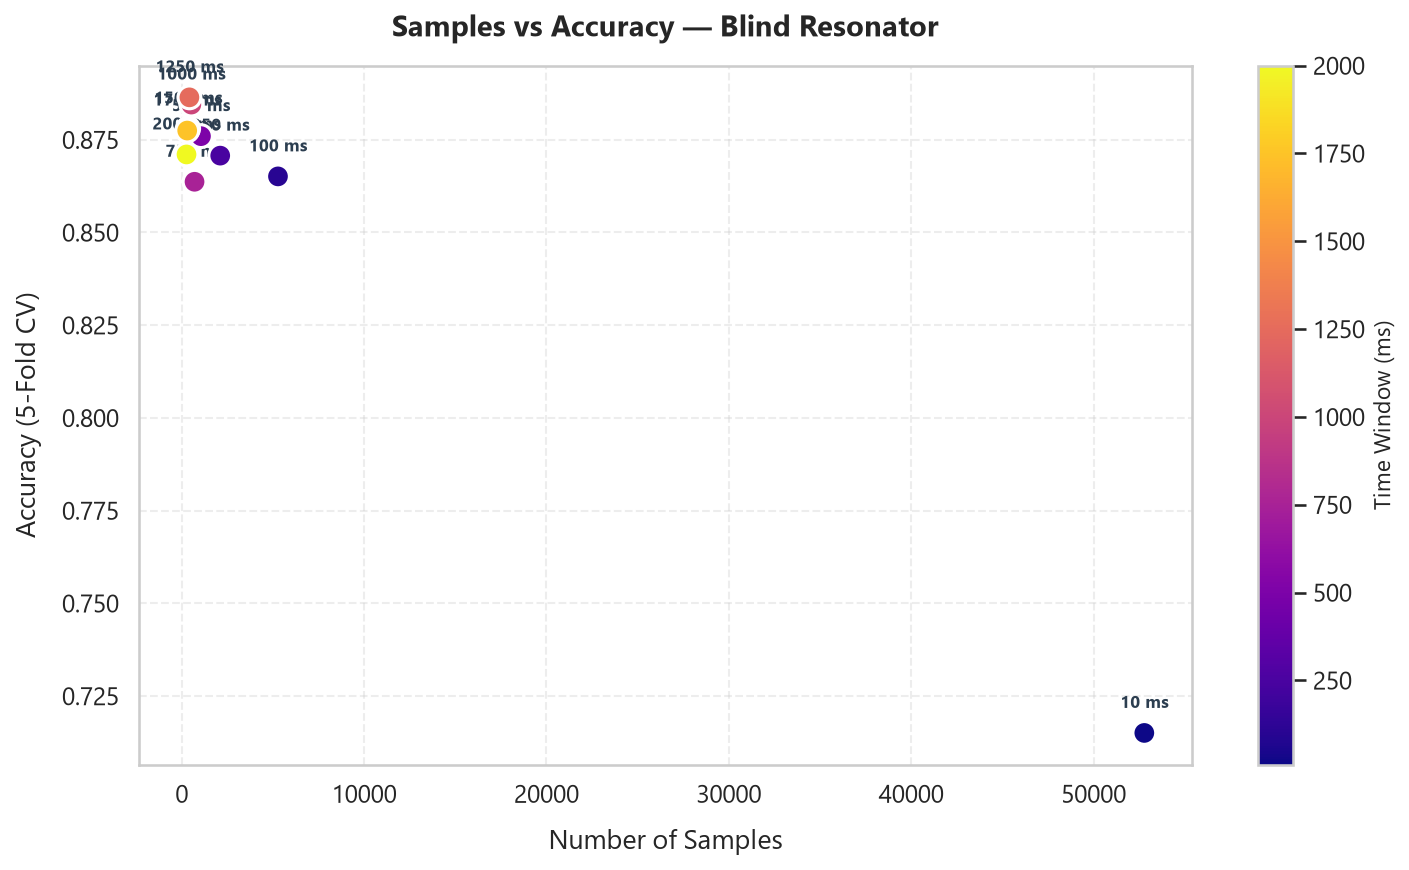

In [15]:
samples_arr = np.array([r['n_samples'] for r in all_results])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(samples_arr, acc_arr, s=120, c=tw_arr,
                     cmap='plasma', edgecolors='white', linewidth=1.5, zorder=4)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Time Window (ms)', fontsize=11)

# Annotate with TW labels
for x, y, tw in zip(samples_arr, acc_arr, tw_arr):
    ax.annotate(f'{int(tw)} ms', (x, y),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8, fontweight='bold', color='#2c3e50')

ax.set_xlabel('Number of Samples', fontsize=13, labelpad=10)
ax.set_ylabel('Accuracy (5-Fold CV)', fontsize=13, labelpad=10)
ax.set_title('Samples vs Accuracy — Blind Resonator',
             fontsize=14, fontweight='bold', pad=14)
ax.grid(True, alpha=0.35, linestyle='--')
plt.tight_layout()
plt.show()

## 14. Best vs Worst Time Window — Side by Side

Direct comparison of the confusion matrices for the best and worst performing time windows.

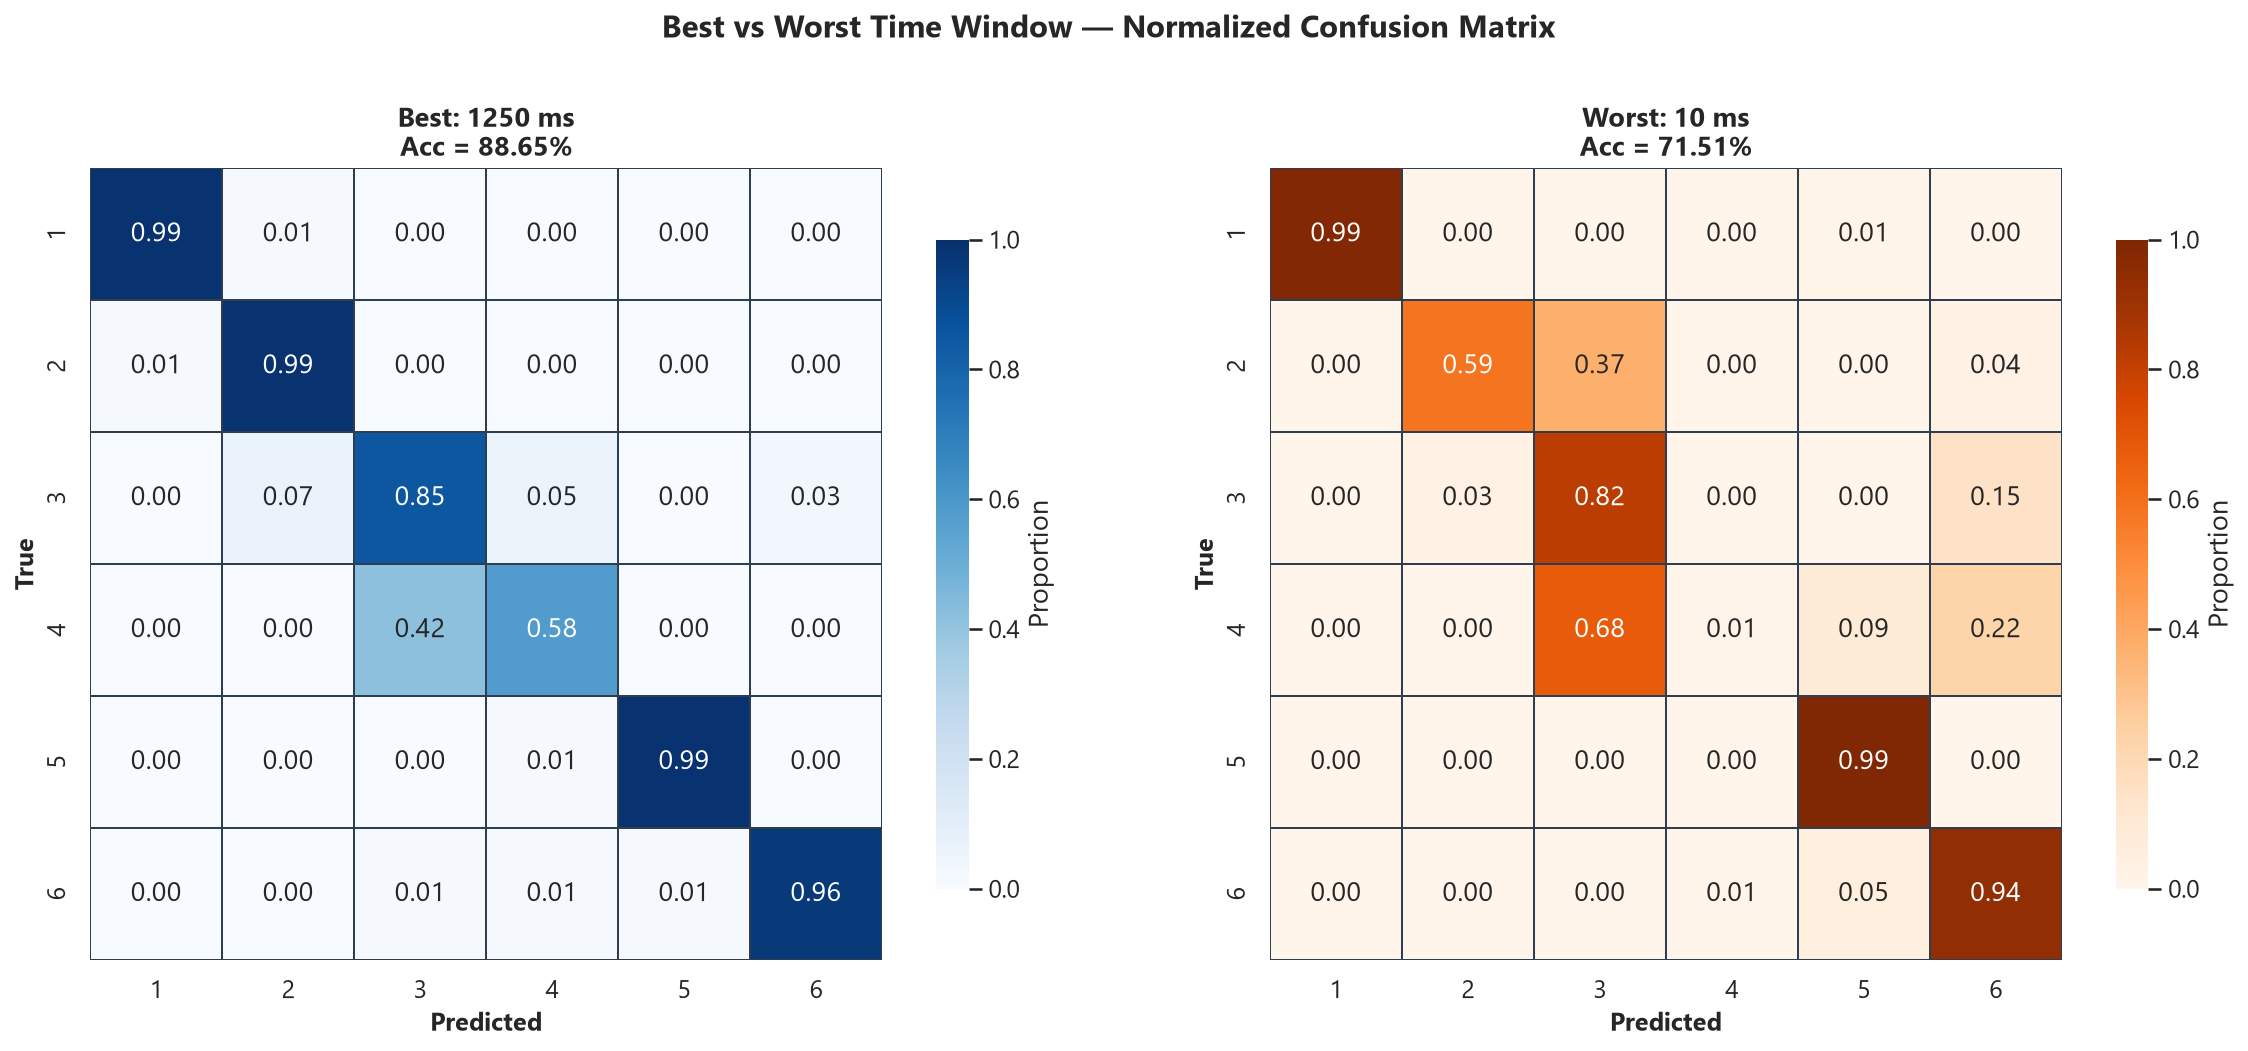

In [16]:
# Find best and worst
best_r = max(all_results, key=lambda r: r['accuracy'])
worst_r = min(all_results, key=lambda r: r['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for ax, r, title_prefix in zip(axes, [best_r, worst_r],
                                 ['Best', 'Worst']):
    labels = sorted(set(r['y_true']) | set(r['y_pred']))
    cm_norm = confusion_matrix(r['y_true'], r['y_pred'],
                               labels=labels, normalize='true')

    annot = np.empty_like(cm_norm, dtype=object)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            annot[i, j] = f"{cm_norm[i, j]:.2f}"

    cmap = 'Blues' if title_prefix == 'Best' else 'Oranges'
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.8, linecolor='#2c3e50',
                vmin=0, vmax=1, square=True, ax=ax,
                cbar_kws={'label': 'Proportion', 'shrink': 0.82})
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('True', fontsize=12, fontweight='bold')
    acc_val = accuracy_score(r['y_true'], r['y_pred'])
    ax.set_title(f"{title_prefix}: {r['time_window']} ms\n"
                 f"Acc = {acc_val*100:.2f}%",
                 fontsize=13, fontweight='bold')

fig.suptitle("Best vs Worst Time Window — Normalized Confusion Matrix",
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()